In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import glob
import pickle
from collections import defaultdict
from pprint import pprint

In [2]:
file_dir = 'spaceinvaderscheckpoint/spaceinvaders_10e6_2.npy'
file_dir = 'thinker-20250806-002733-4000032-1/video_stat.npy'
file_dir = 'thinker-20251124-205000-261840-0/video_stat.npy'
#file_dir = 'thinker-20251023-165530-327280-0/video_stat.npy'
#file_dir = 'test/spaceinvaders_9e6_1.npy'
data_dir = os.path.join('./test', file_dir)
data = (np.load(data_dir, allow_pickle=True)).item()
print('data.keys():', data.keys())
print('real image data length:', len(data['real_imgs']))
print('imagination image data length:', len(data['im_imgs']))

data.keys(): dict_keys(['real_imgs', 'im_imgs', 'status', 'tree_reps', 'env_return', 'cur_rewards', 'step_times', 'tree_reps_vector', 'real_vectors', 'im_vectors', 'im_vp_vectors'])
real image data length: 35022
imagination image data length: 35022


In [ ]:
iidx0 = next(i for i, s in enumerate(data["status"]) if s == 0)
tree_rep_sample = {k: v[idx0] for k, v in data["tree_reps"].items()}

print(f"status==0 sample index: {idx0}")
for key, value in tree_rep_sample.items():
    print(f"{key}:\n{value}\n")

In [3]:
# data['status']에서 각 값의 개수 계산
status_values = [0, 1, 2, 3]  # 계산하려는 status 값들
status_counts = {}

for value in status_values:
    # 해당 값을 가진 인덱스의 개수 계산
    count = np.sum(np.array(data['status']) == value)
    status_counts[value] = count

# 결과 출력
for value, count in status_counts.items():
    status_name = {
        0: "실제 스텝(real step)",
        1: "리셋(reset)",
        2: "상상 스텝(imaginary step)",
        3: "강제 리셋(force reset)"
    }.get(value, "알 수 없음")
    
    print(f"Status {value} ({status_name}): {count}개")

# 특정 값(예: 0)을 가진 인덱스 목록 구하기
indices_with_value_1 = np.where(np.array(data['status']) == 1)[0]
print(f"\nStatus 1을 가진 인덱스의 개수: {len(indices_with_value_1)}")

Status 0 (실제 스텝(real step)): 736개
Status 1 (리셋(reset)): 5026개
Status 2 (상상 스텝(imaginary step)): 28665개
Status 3 (강제 리셋(force reset)): 595개

Status 1을 가진 인덱스의 개수: 5026


In [4]:
def analyze_status_data(status_data):
    """
    status 데이터를 분석하여 real step과 imaginary step을 구분하고
    각 real step마다의 planning depth를 계산합니다.
    
    새로운 방식: 0부터 다음 0까지를 하나의 stage로 간주하되,
    그 사이에 1,3이 있으면 끊어서 계산하고, 각 구간의 길이들의 평균을 planning depth로 사용합니다.
    
    Args:
        status_data: status 값들의 배열 (0, 1, 2, 3 중 하나의 값)
    
    Returns:
        real_indices: real step의 인덱스들
        planning_depths: 각 real step마다의 planning depth 값 (평균값)
        reset_info: 리셋 정보 (각 imagination 구간에서 리셋이 발생한 위치)
    """
    real_indices = []
    planning_depths = []  # 각 real step마다의 planning depth 값 (평균값)
    reset_info = []
    
    i = 0
    while i < len(status_data):
        # status가 0인 real step 찾기
        if status_data[i] == 0:
            real_indices.append(i)
            
            # 다음 real step(status=0)까지의 imagination 구간 찾기
            imagination_start = i + 1
            imagination_end = len(status_data)  # 기본값: 끝까지
            
            # 다음 real step 찾기
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break
            
            # imagination 구간에서의 planning depth 계산 (새로운 방식)
            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                
                # 1과 3을 만나면 끊어서 각 구간의 길이 계산
                segment_lengths = []
                current_length = 0
                reset_positions = []
                
                for k, status_val in enumerate(imagination_segment):
                    if status_val in [1, 3]:  # 리셋 발생 (1 또는 3)
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:  # 상상 스텝 (2)
                        current_length += 1
                    # status_val == 0인 경우는 이미 처리됨
                
                # 마지막 구간 추가
                if current_length > 0:
                    segment_lengths.append(current_length)
                
                # planning depth는 각 구간의 길이들의 평균
                if segment_lengths:
                    avg_planning_depth = np.mean(segment_lengths)
                else:
                    avg_planning_depth = 0.0
                
                planning_depths.append(avg_planning_depth)
                
                reset_info.append({
                    'reset_positions': reset_positions,
                    'segment_lengths': segment_lengths,
                    'total_length': sum(segment_lengths),
                    'avg_planning_depth': avg_planning_depth
                })
            else:
                planning_depths.append(0.0)
                reset_info.append({
                    'reset_positions': [],
                    'segment_lengths': [],
                    'total_length': 0,
                    'avg_planning_depth': 0.0
                })
            
            i = imagination_end
        else:
            i += 1
    
    return real_indices, planning_depths, reset_info

# 데이터 로드 및 분석
status_data = data['status']
real_indices, imagination_lengths, reset_info = analyze_status_data(status_data)

In [5]:
def analyze_noop_planning_relationship(data, window_size=10, stride=2):
    """
    Sliding window를 사용하여 NOOP action 빈도와 planning depth의 관계를 분석합니다.
    status가 0인 real step 데이터만 분석 대상으로 합니다.
    
    Args:
        data: 로드된 데이터 딕셔너리
        window_size: sliding window 크기 (real step 기준)
        stride: sliding 간격 (real step 기준)
    
    Returns:
        window_results: 각 윈도우별 분석 결과
    """
    status_data = data['status']
    total_length = len(status_data)
    
    # status 데이터 분석 (planning depth 계산용) - 새로운 방식 사용
    real_indices, planning_depths, reset_info = analyze_status_data(status_data)
    
    # NOOP action 추출 (one-hot encoding 처리)
    noop_actions = []
    for idx in range(total_length):
        if idx < len(data['tree_reps']['cur_action']):
            action_onehot = data['tree_reps']['cur_action'][idx]
            action_idx = np.argmax(action_onehot)
            noop_actions.append(action_idx)
        else:
            noop_actions.append(-1)  # 데이터가 없는 경우
    
    noop_actions = np.array(noop_actions)
    
    # status가 0인 real step에서만 NOOP action 추출
    real_step_noop_actions = []
    for idx in real_indices:
        if idx < len(noop_actions):
            real_step_noop_actions.append(noop_actions[idx])
        else:
            real_step_noop_actions.append(-1)
    
    real_step_noop_actions = np.array(real_step_noop_actions)
    
    window_results = []
    
    # Real step 기준으로 sliding window 분석
    for start_idx in range(0, len(real_indices) - window_size + 1, stride):
        end_idx = start_idx + window_size
        
        # 현재 윈도우의 real step 인덱스들
        window_real_indices = real_indices[start_idx:end_idx]
        window_noop_actions = real_step_noop_actions[start_idx:end_idx]
        window_planning_depths = planning_depths[start_idx:end_idx]
        
        # 1. NOOP action 분석 (real step에서만)
        noop_count = np.sum(window_noop_actions == 0)  # NOOP = 0
        noop_frequency = noop_count / window_size
        
        # 2. Planning depth 분석 - 윈도우 내 모든 real step의 planning depth 평균
        avg_planning_depth = np.mean(window_planning_depths)
        
        # 3. 결과 저장
        window_result = {
            'window_start': start_idx,
            'window_end': end_idx,
            'real_step_indices': window_real_indices,
            'noop_count': noop_count,
            'noop_frequency': noop_frequency,
            'avg_planning_depth': avg_planning_depth,
            'planning_depths': window_planning_depths,
            'noop_actions': window_noop_actions
        }
        
        window_results.append(window_result)
    
    return window_results

# 데이터 로드 및 분석
status_data = data['status']
real_indices, planning_depths, reset_info = analyze_status_data(status_data)

print(f"총 데이터 길이: {len(status_data)}")
print(f"Real step 개수: {len(real_indices)}")

if planning_depths:
    print(f"Planning Depth 통계 (각 real step별 평균값):")
    print(f"  - 평균: {np.mean(planning_depths):.2f}")
    print(f"  - 중앙값: {np.median(planning_depths):.2f}")
    print(f"  - 최대값: {np.max(planning_depths):.2f}")
    print(f"  - 최소값: {np.min(planning_depths):.2f}")
    print(f"  - 표준편차: {np.std(planning_depths):.2f}")
else:
    print("Planning depth 데이터가 없습니다.")

# 각 real step마다의 구간 수 통계
segment_counts = [len(info['segment_lengths']) for info in reset_info]
print(f"\n각 real step마다의 구간 수 통계:")
print(f"  - 평균: {np.mean(segment_counts):.2f}")
print(f"  - 중앙값: {np.median(segment_counts):.2f}")
print(f"  - 최대값: {np.max(segment_counts)}")
print(f"  - 최소값: {np.min(segment_counts)}")
print(f"  - 표준편차: {np.std(segment_counts):.2f}")

# 예시 출력 (처음 몇 개 real step의 planning depth)
print(f"\n=== 예시: 처음 5개 real step의 planning depth ===")
for i in range(min(5, len(planning_depths))):
    print(f"Real step {i+1} (인덱스 {real_indices[i]}): "
          f"Planning Depth = {planning_depths[i]:.2f}, "
          f"구간들 = {reset_info[i]['segment_lengths']}")

총 데이터 길이: 35022
Real step 개수: 736
Planning Depth 통계 (각 real step별 평균값):
  - 평균: 8.31
  - 중앙값: 7.80
  - 최대값: 39.00
  - 최소값: 0.00
  - 표준편차: 5.53

각 real step마다의 구간 수 통계:
  - 평균: 7.25
  - 중앙값: 5.00
  - 최대값: 31
  - 최소값: 0
  - 표준편차: 5.51

=== 예시: 처음 5개 real step의 planning depth ===
Real step 1 (인덱스 0): Planning Depth = 13.00, 구간들 = [23, 1, 15]
Real step 2 (인덱스 43): Planning Depth = 4.88, 구간들 = [9, 5, 5, 7, 6, 2, 4, 1]
Real step 3 (인덱스 92): Planning Depth = 4.88, 구간들 = [6, 2, 11, 2, 2, 13, 1, 2]
Real step 4 (인덱스 140): Planning Depth = 9.75, 구간들 = [25, 1, 12, 1]
Real step 5 (인덱스 185): Planning Depth = 2.05, 구간들 = [7, 3, 1, 7, 1, 2, 1, 2, 2, 2, 1, 1, 3, 1, 1, 1, 1, 1, 1]


In [6]:
data['cur_rewards'][0:60]

array([[0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 1.0000000e+00],
       [0.0000000e+00, 4.1821003e-03],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 4.2033315e-01],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 9.9611282e-04],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.0000000e+00],
       [0.0000000e+00, 0.

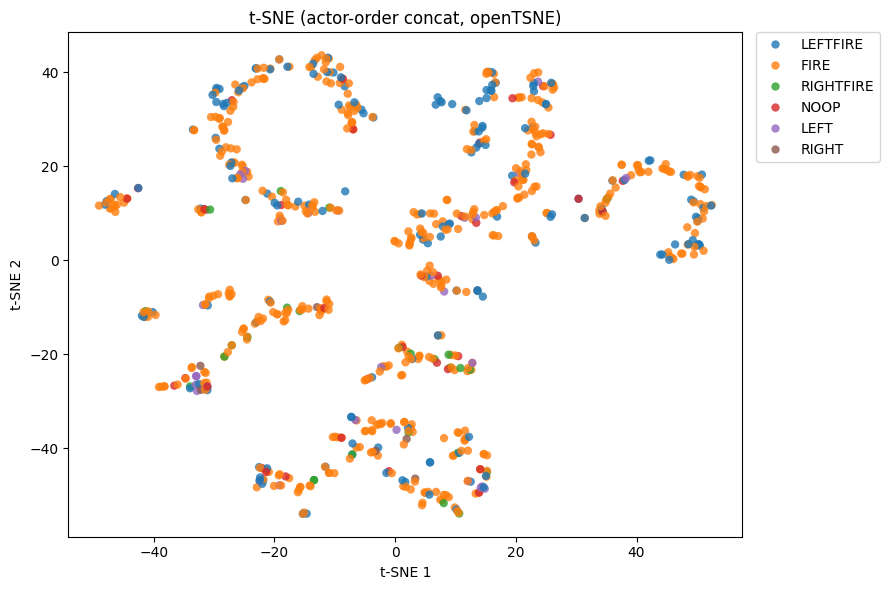

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from openTSNE import TSNE, affinity, initialization

# ActorNet concat 우선순위
ACTOR_ORDER = [
    "last_pri", "last_reset", "last_reward",
    "tree_reps_vector", "h_vectors", "im_vectors", "real_vectors",
    "im_vp_vectors", "im_imgs",
]

action_mapping = {"NOOP": 0, "FIRE": 1, "RIGHT": 2, "LEFT": 3, "RIGHTFIRE": 4, "LEFTFIRE": 5}
idx_to_action = {v: k for k, v in action_mapping.items()}

def _normalize_specs(specs):
    if specs is None:
        return []
    if isinstance(specs, str):
        return [specs]
    return list(specs)

def _order_specs_by_actor(specs):
    # 주어진 선택지(specs)만 남기고 actor concat 우선순위에 맞춰 정렬
    present = set(specs)
    ordered = [k for k in ACTOR_ORDER if k in present]
    # None/미지정 항목은 맨 뒤
    ordered.extend([k for k in specs if k not in ordered])
    return ordered

def _flatten(arr, max_len):
    arr = np.asarray(arr)
    arr = arr[:max_len]
    return arr.reshape(arr.shape[0], -1).astype(np.float32)

def vectorize_by_specs(data, specs):
    entries, lengths = [], []
    for key in specs:
        if key in data and not isinstance(data[key], dict):
            arr = np.asarray(data[key])
            entries.append(arr)
            lengths.append(arr.shape[0])
        elif key == "tree_reps_vector":
            # tree_reps 전체를 필드 순서 그대로 평탄화
            flat_parts = []
            for v in data["tree_reps"].values():
                flat_parts.append(np.asarray(v))
                lengths.append(np.asarray(v).shape[0])
            common_len = min(lengths) if lengths else len(data["status"])
            flat_parts = [_flatten(v, common_len) for v in flat_parts]
            entries.append(np.concatenate(flat_parts, axis=1))
        else:
            # key가 dict이면 모든 필드를 concat
            if key in data and isinstance(data[key], dict):
                parts = [np.asarray(v) for v in data[key].values()]
                lengths.extend([p.shape[0] for p in parts])
                common_len = min(lengths)
                parts = [_flatten(p, common_len) for p in parts]
                entries.append(np.concatenate(parts, axis=1))
    if not entries:
        raise ValueError("선택된 feature가 없습니다.")
    common_len = min([e.shape[0] for e in entries])
    entries = [e[:common_len].reshape(common_len, -1) for e in entries]
    return np.concatenate(entries, axis=1), common_len

def pair_planning_before_real(status):
    status = np.asarray(status)
    real_idx = np.where(status == 0)[0]
    driver_idx = real_idx - 1
    mask = driver_idx >= 0
    return real_idx[mask], driver_idx[mask]

def prepare_feature_matrix(data, feature_specs=None):
    specs = _normalize_specs(feature_specs)
    specs = _order_specs_by_actor(specs)
    feature_matrix, max_len = vectorize_by_specs(data, specs)

    status = np.asarray(data["status"])[:max_len]
    real_idx, driver_idx = pair_planning_before_real(status)

    feature_subset = feature_matrix[driver_idx]

    cur_action = np.asarray(data["tree_reps"]["cur_action"][:max_len])
    action_ids = np.argmax(cur_action, axis=1)
    action_labels = np.array([idx_to_action.get(i, f"A{i}") for i in action_ids])[real_idx]

    # planning depth 표시(선택적)
    if "analyze_status_data" in globals():
        all_real_idx, depths, _ = analyze_status_data(status)
        depth_map = {idx: depth for idx, depth in zip(all_real_idx, depths)}
        planning_depths = np.array([depth_map.get(idx, np.nan) for idx in real_idx])
    else:
        planning_depths = np.full(real_idx.shape, np.nan)

    return feature_subset, action_labels, planning_depths, driver_idx, real_idx

def fit_tsne_opentsne(feature_matrix, perplexity=35, random_state=0, pca_dim=50):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(feature_matrix)

    # PCA 축소 (특징 수보다 크게 잡히면 자동으로 축소)
    pca_k = min(pca_dim, scaled.shape[1])
    pca = PCA(n_components=pca_k, random_state=random_state)
    reduced = pca.fit_transform(scaled)

    base = max(5, int(perplexity))
    perps = sorted({base, max(base * 5, base + 1)})
    aff = affinity.Multiscale(
        reduced,
        perplexities=perps,
        method="approx",
        metric="euclidean",
        n_jobs=-1,
        random_state=random_state,
    )
    init = initialization.pca(reduced, random_state=random_state)
    tsne = TSNE(
        n_components=2,
        n_jobs=-1,
        negative_gradient_method="fft",
        early_exaggeration_iter=250,
        early_exaggeration=12,
        n_iter=750,
        random_state=random_state,
    )
    emb = tsne.fit(affinities=aff, initialization=init)
    if len(perps) > 1:
        aff.set_perplexities([float(min(perps))])
        emb = emb.optimize(n_iter=250, exaggeration=1, momentum=0.8)
    return np.asarray(emb)

def plot_tsne(data, feature_specs, perplexity=35, random_state=0, pca_dim=50):
    feats, action_labels, planning_depths, driver_idx, real_idx = prepare_feature_matrix(
        data, feature_specs=feature_specs
    )
    if feats.shape[0] <= perplexity:
        raise ValueError("perplexity는 샘플 수보다 작아야 합니다.")
    emb = fit_tsne_opentsne(feats, perplexity=perplexity, random_state=random_state, pca_dim=pca_dim)

    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        x=emb[:, 0],
        y=emb[:, 1],
        hue=action_labels,
        palette="tab10",
        alpha=0.8,
        edgecolor="none",
    )
    plt.title("t-SNE (actor-order concat, openTSNE)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.0)
    plt.tight_layout()
    plt.show()

    return {
        "tsne_1": emb[:, 0],
        "tsne_2": emb[:, 1],
        "action": action_labels,
        "planning_depth": planning_depths,
        "driver_idx": driver_idx,
        "action_idx": real_idx,
    }

# 예시 실행
tsne_results = plot_tsne(
    data,
    feature_specs=["tree_reps_vector", 'im_imgs', 'im_vectors', 'im_vp_vectors'],
    perplexity=10,
    random_state=0,
    pca_dim = 50
)


In [2]:
"""Utilities for visualizing behavioral embeddings across checkpoints.

These helpers iterate over every ``.npy`` file inside a folder, extract the
planning snapshot that immediately precedes each real action (status==0), and
render t‑SNE plots where each real action inherits the hue (action id) and
training step brightness.  The pairing logic works for tree_reps, real_imgs,
real_vectors, etc., so you can compare multiple targets in one run.
"""

from __future__ import annotations

import math
import os
import re
from pathlib import Path
from typing import List, Optional, Sequence, Tuple, Union, Sequence as SeqLike

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------------------------
# Shared constants/helpers
# ---------------------------------------------------------------------------

ACTION_MAPPING = {
    "NOOP": 0,
    "FIRE": 1,
    "RIGHT": 2,
    "LEFT": 3,
    "RIGHTFIRE": 4,
    "LEFTFIRE": 5,
}
IDX_TO_ACTION = {v: k for k, v in ACTION_MAPPING.items()}

TRAINING_STEP_IN_NAME = re.compile(r"_(\d+(?:e\d+)?)(?=(?:_\d+)?\.npy$)", re.IGNORECASE)
TRAINING_STEP_IN_DIR = re.compile(r"(\d+(?:e\d+)?)$", re.IGNORECASE)
ALL_FIELD_SENTINELS = {"tree_reps", "all", "ALL", "*"}
EXCLUDED_TREE_REP_FIELDS = {}


def _format_training_step(step: float) -> str:
    if step >= 1_000_000:
        return f"{step/1_000_000:.1f}M"
    if step >= 1_000:
        return f"{step/1_000:.1f}K"
    return f"{int(step)}"


# ---------------------------------------------------------------------------
# Status / pairing utilities
# ---------------------------------------------------------------------------

def analyze_status_data(status_data: Sequence[int]) -> Tuple[List[int], List[float], List[dict]]:
    real_indices: List[int] = []
    planning_depths: List[float] = []
    reset_info: List[dict] = []

    i = 0
    while i < len(status_data):
        if status_data[i] == 0:
            real_indices.append(i)
            imagination_start = i + 1
            imagination_end = len(status_data)
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break

            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                segment_lengths: List[int] = []
                current_length = 0
                reset_positions: List[int] = []

                for k, status_val in enumerate(imagination_segment):
                    if status_val in (1, 3):
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:
                        current_length += 1

                if current_length > 0:
                    segment_lengths.append(current_length)

                avg_planning_depth = float(np.mean(segment_lengths)) if segment_lengths else 0.0
                planning_depths.append(avg_planning_depth)
                reset_info.append(
                    {
                        "reset_positions": reset_positions,
                        "segment_lengths": segment_lengths,
                        "total_length": sum(segment_lengths),
                        "avg_planning_depth": avg_planning_depth,
                    }
                )
            else:
                planning_depths.append(0.0)
                reset_info.append(
                    {
                        "reset_positions": [],
                        "segment_lengths": [],
                        "total_length": 0,
                        "avg_planning_depth": 0.0,
                    }
                )

            i = imagination_end
        else:
            i += 1

    return real_indices, planning_depths, reset_info


def pair_real_and_planning_indices(status_data: Sequence[int]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    status_arr = np.asarray(status_data)
    real_indices, planning_depths_forward, _ = analyze_status_data(status_arr)

    paired_real: List[int] = []
    planning_indices: List[int] = []
    paired_depths: List[float] = []

    for pos in range(1, len(real_indices)):
        real_idx = real_indices[pos]
        cand = real_idx - 1
        while cand >= 0 and status_arr[cand] == 0:
            cand -= 1
        if cand < 0:
            continue
        paired_real.append(real_idx)
        planning_indices.append(cand)
        paired_depths.append(planning_depths_forward[pos - 1])

    return (
        np.asarray(paired_real, dtype=np.int64),
        np.asarray(planning_indices, dtype=np.int64),
        np.asarray(paired_depths, dtype=np.float32),
    )


def _normalize_tree_fields(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]]
) -> List[str]:
    if tree_fields is None:
        return [
            k
            for k, v in tree_reps.items()
            if isinstance(v, np.ndarray) and k not in EXCLUDED_TREE_REP_FIELDS
        ]

    if isinstance(tree_fields, str):
        if tree_fields in ALL_FIELD_SENTINELS:
            return _normalize_tree_fields(tree_reps, None)
        tree_fields = [tree_fields]

    filtered_fields = [f for f in tree_fields if f not in ALL_FIELD_SENTINELS]
    filtered_fields = [f for f in filtered_fields if f not in EXCLUDED_TREE_REP_FIELDS]
    if not filtered_fields:
        return _normalize_tree_fields(tree_reps, None)

    resolved = []
    missing = []
    for field in filtered_fields:
        if field in tree_reps:
            resolved.append(field)
        else:
            missing.append(field)

    if missing:
        raise KeyError(f"Missing tree_rep fields: {missing}")

    return resolved


def vectorize_tree_reps(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]] = None
) -> Tuple[np.ndarray, int]:
    fields = _normalize_tree_fields(tree_reps, tree_fields)
    lengths = [tree_reps[k].shape[0] for k in fields]
    common_len = int(min(lengths))

    vectors = []
    for key in fields:
        arr = np.asarray(tree_reps[key][:common_len])
        vectors.append(arr.reshape(common_len, -1))

    return np.concatenate(vectors, axis=1), common_len


def _flatten_step_array(arr: np.ndarray, max_len: Optional[int] = None) -> Tuple[np.ndarray, int]:
    arr = np.asarray(arr)
    if max_len is not None:
        arr = arr[:max_len]
    if arr.ndim == 1:
        flat = arr.reshape(arr.shape[0], 1)
    else:
        flat = arr.reshape(arr.shape[0], -1)
    return flat, flat.shape[0]


def prepare_real_step_matrix(
    data: dict,
    source: str = "tree_reps",
    tree_fields: Optional[Union[str, Sequence[str]]] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    status_data = np.asarray(data["status"])
    real_indices, planning_indices, planning_depths = pair_real_and_planning_indices(status_data)

    if len(real_indices) == 0:
        raise ValueError("No usable real/planning pairs found.")

    if source == "tree_reps":
        matrix, common_len = vectorize_tree_reps(data["tree_reps"], tree_fields=tree_fields)
    else:
        if source not in data:
            raise KeyError(f"Source '{source}' not present in data keys: {list(data.keys())}")
        limit = min(len(data[source]), len(status_data))
        matrix, common_len = _flatten_step_array(data[source], max_len=limit)

    root_action_full = np.asarray(data["tree_reps"]["root_action"])
    root_len = root_action_full.shape[0]

    valid = (planning_indices < common_len) & (real_indices < root_len)
    if not np.any(valid):
        raise ValueError(f"No valid indices remain after aligning '{source}' with status array.")

    planning_indices = planning_indices[valid]
    real_indices = real_indices[valid]
    planning_depths = planning_depths[valid]

    features = matrix[planning_indices]
    action_ids = np.argmax(root_action_full[real_indices], axis=1)

    return features, action_ids, planning_depths, real_indices, planning_indices


# ---------------------------------------------------------------------------
# Dataset aggregation
# ---------------------------------------------------------------------------

def extract_training_step(path_like: Union[str, os.PathLike]) -> int:
    path = Path(path_like)
    name_match = TRAINING_STEP_IN_NAME.search(path.name)
    if name_match:
        token = name_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    dir_match = TRAINING_STEP_IN_DIR.search(path.parent.name)
    if dir_match:
        token = dir_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    for part in reversed(path.parent.parts):
        if part.startswith("thinker-"):
            chunks = part.split("-")
            for chunk in reversed(chunks):
                if chunk.isdigit() or TRAINING_STEP_IN_DIR.match(chunk or ""):
                    try:
                        return int(float(chunk))
                    except ValueError:
                        continue
    return 0


def build_tree_rep_dataset(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    source: str = "tree_reps",
    max_files: Optional[int] = None,
    stride: int = 1,
    logger=print,
) -> dict:
    folder = Path(root_folder)
    npy_files = sorted(folder.glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError(f"No .npy files found under {folder}")

    all_vectors: List[np.ndarray] = []
    all_actions: List[np.ndarray] = []
    all_labels: List[np.ndarray] = []
    all_planning: List[np.ndarray] = []
    all_steps: List[np.ndarray] = []
    all_sources: List[np.ndarray] = []
    all_real_idx: List[np.ndarray] = []
    all_plan_idx: List[np.ndarray] = []

    for idx, npy_path in enumerate(npy_files):
        if max_files is not None and idx >= max_files:
            break
        try:
            data = np.load(npy_path, allow_pickle=True).item()
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to load {npy_path.name}: {exc}")
            continue

        try:
            (
                tree_real,
                action_ids,
                planning_depths,
                real_indices,
                planning_indices,
            ) = prepare_real_step_matrix(
                data, source=source, tree_fields=tree_fields
            )
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to parse {npy_path.name}: {exc}")
            continue

        if stride > 1:
            tree_real = tree_real[::stride]
            action_ids = action_ids[::stride]
            planning_depths = planning_depths[::stride]
            real_indices = real_indices[::stride]
            planning_indices = planning_indices[::stride]

        if tree_real.size == 0:
            continue

        training_step = extract_training_step(npy_path)
        step_arr = np.full(tree_real.shape[0], training_step, dtype=np.int64)
        source_arr = np.array([npy_path.name] * tree_real.shape[0])
        action_labels = np.vectorize(lambda a: IDX_TO_ACTION.get(int(a), f"A{int(a)}"))(action_ids)

        all_vectors.append(tree_real)
        all_actions.append(action_ids)
        all_labels.append(action_labels)
        all_planning.append(planning_depths)
        all_steps.append(step_arr)
        all_sources.append(source_arr)
        all_real_idx.append(real_indices.astype(np.int64))
        all_plan_idx.append(planning_indices.astype(np.int64))

        if logger:
            logger(
                f"[loaded] {npy_path.name:<35s} "
                f"pairs={tree_real.shape[0]:5d}  step={_format_training_step(training_step)}  source={source}"
            )

    if not all_vectors:
        raise RuntimeError(f"No usable tree_reps found under {folder}.")

    def _stack(chunks: List[np.ndarray]) -> np.ndarray:
        return np.concatenate(chunks, axis=0)

    dataset = {
        "tree_matrix": _stack(all_vectors),
        "action_ids": _stack(all_actions),
        "action_labels": _stack(all_labels),
        "planning_depths": _stack(all_planning),
        "training_steps": _stack(all_steps),
        "source_files": _stack(all_sources),
        "real_indices": _stack(all_real_idx),
        "planning_indices": _stack(all_plan_idx),
    }

    return dataset


# ---------------------------------------------------------------------------
# Visualization helpers
# ---------------------------------------------------------------------------

def _mix_with_white(color: Union[str, Sequence[float]], strength: float) -> Tuple[float, float, float]:
    rgb = np.asarray(mcolors.to_rgb(color))
    strength = float(np.clip(strength, 0.0, 1.0))
    return tuple(rgb * (1.0 - strength) + strength)


def _compute_point_colors(action_ids: np.ndarray, training_steps: np.ndarray) -> Tuple[List[Tuple[float, float, float]], dict]:
    unique_actions = sorted(np.unique(action_ids))
    base_palette = sns.color_palette("tab10", n_colors=max(10, len(unique_actions)))
    base_color_map = {
        action: base_palette[action % len(base_palette)] for action in unique_actions
    }

    min_step = float(training_steps.min())
    max_step = float(training_steps.max())
    if math.isclose(min_step, max_step):
        norm = np.zeros_like(training_steps, dtype=float)
    else:
        norm = (training_steps - min_step) / (max_step - min_step)
    strengths = 0.15 + 0.7 * norm

    colors = []
    for action_id, strength in zip(action_ids, strengths):
        base = base_color_map[action_id]
        colors.append(_mix_with_white(base, float(strength)))

    return colors, base_color_map


def fit_tsne(tree_matrix: np.ndarray, perplexity: int = 30, random_state: int = 0) -> np.ndarray:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(tree_matrix)
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        max_iter=2000,
        verbose=1,
    )
    return tsne.fit_transform(scaled)


def plot_tree_rep_tsne_for_folder(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    source: str = "tree_reps",
    perplexity: int = 35,
    random_state: int = 0,
    stride: int = 1,
    max_files: Optional[int] = None,
) -> dict:
    dataset = build_tree_rep_dataset(
        root_folder=root_folder,
        tree_fields=tree_fields,
        source=source,
        max_files=max_files,
        stride=stride,
    )
    emb = fit_tsne(dataset["tree_matrix"], perplexity=perplexity, random_state=random_state)
    colors_with_brightness, base_color_map = _compute_point_colors(
        dataset["action_ids"], dataset["training_steps"]
    )
    pure_colors = [base_color_map[a] for a in dataset["action_ids"]]

    if source == "tree_reps":
        if tree_fields is None:
            fields_label = "all fields"
        elif isinstance(tree_fields, (list, tuple)):
            fields_label = " + ".join(tree_fields)
        else:
            fields_label = str(tree_fields)
        title_suffix = f" ({fields_label})"
    else:
        title_suffix = ""

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

    axes[0].scatter(emb[:, 0], emb[:, 1], c=colors_with_brightness, s=18, linewidths=0, alpha=0.95)
    axes[0].set_title(f"t-SNE [{source}]{title_suffix}\nHue = action, brightness = training step")
    axes[0].set_xlabel("t-SNE 1")
    axes[0].set_ylabel("t-SNE 2")

    axes[1].scatter(emb[:, 0], emb[:, 1], c=pure_colors, s=18, linewidths=0, alpha=0.95)
    axes[1].set_title(f"t-SNE [{source}] (no brightness)\nHue = action only")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")

    action_handles = [
        Line2D([0], [0], marker="o", linestyle="", color=base_color_map[action], label=f"{IDX_TO_ACTION.get(action, action)} ({action})")
        for action in sorted(base_color_map)
    ]
    legend_actions = axes[0].legend(
        handles=action_handles,
        title="Action (base hue)",
        loc="upper right",
        bbox_to_anchor=(1.32, 1.0),
    )
    axes[0].add_artist(legend_actions)

    unique_steps = np.unique(dataset["training_steps"])
    sample_steps = unique_steps
    if unique_steps.size > 5:
        quantiles = np.linspace(0.0, 1.0, num=5)
        sample_steps = np.unique(np.round(np.quantile(unique_steps, quantiles)).astype(int))

    def _strength_for_step(step_val: float) -> float:
        min_step = float(unique_steps.min())
        max_step = float(unique_steps.max())
        if math.isclose(min_step, max_step):
            return 0.35
        norm = (step_val - min_step) / (max_step - min_step)
        return 0.15 + 0.7 * norm

    step_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            color=_mix_with_white("black", _strength_for_step(step)),
            label=_format_training_step(float(step)),
        )
        for step in sample_steps
    ]
    axes[0].legend(
        handles=step_handles,
        title="Training step\n(brightness only)",
        loc="lower right",
        bbox_to_anchor=(1.32, 0.0),
    )

    plt.tight_layout()
    plt.show()

    tsne_table = {
        "tsne_1": emb[:, 0],
        "tsne_2": emb[:, 1],
        "action_id": dataset["action_ids"],
        "action_label": dataset["action_labels"],
        "training_step": dataset["training_steps"],
        "planning_depth": dataset["planning_depths"],
        "source_file": dataset["source_files"],
        "real_index": dataset["real_indices"],
        "planning_index": dataset["planning_indices"],
    }

    return tsne_table



def plot_multiple_tsne_targets(
    root_folder: Union[str, os.PathLike],
    configs: Optional[Sequence[dict]] = None,
    shared_kwargs: Optional[dict] = None,
) -> dict:
    shared_kwargs = dict(shared_kwargs) if shared_kwargs else {}
    if configs is None:
        configs = [
            {"name": "tree_reps", "source": "tree_reps"},
            {"name": "real_imgs", "source": "real_imgs"},
            {"name": "real_vectors", "source": "real_vectors"},
        ]

    results = {}
    for cfg in configs:
        cfg = cfg.copy()
        name = cfg.pop("name", cfg.get("source", "tree_reps"))
        print("=" * 80)
        print(f"[t-SNE] {name}")
        local_kwargs = {**shared_kwargs, **cfg}
        results[name] = plot_tree_rep_tsne_for_folder(
            root_folder=root_folder,
            **local_kwargs,
        )

    return results




[t-SNE] tree_reps
[loaded] spaceinvaders_10e6_0.npy            pairs= 2219  step=10.0M  source=tree_reps
[loaded] spaceinvaders_10e6_1.npy            pairs= 3564  step=10.0M  source=tree_reps
[loaded] spaceinvaders_10e6_2.npy            pairs= 3481  step=10.0M  source=tree_reps
[loaded] spaceinvaders_1e6_0.npy             pairs= 1007  step=1.0M  source=tree_reps
[loaded] spaceinvaders_1e6_1.npy             pairs=  852  step=1.0M  source=tree_reps
[loaded] spaceinvaders_1e6_2.npy             pairs=  947  step=1.0M  source=tree_reps
[loaded] spaceinvaders_2e6_0.npy             pairs=  855  step=2.0M  source=tree_reps
[loaded] spaceinvaders_2e6_1.npy             pairs=  908  step=2.0M  source=tree_reps
[loaded] spaceinvaders_2e6_2.npy             pairs= 1106  step=2.0M  source=tree_reps
[loaded] spaceinvaders_3e6_0.npy             pairs=  943  step=3.0M  source=tree_reps
[loaded] spaceinvaders_3e6_1.npy             pairs=  890  step=3.0M  source=tree_reps
[loaded] spaceinvaders_3e6_2.npy 

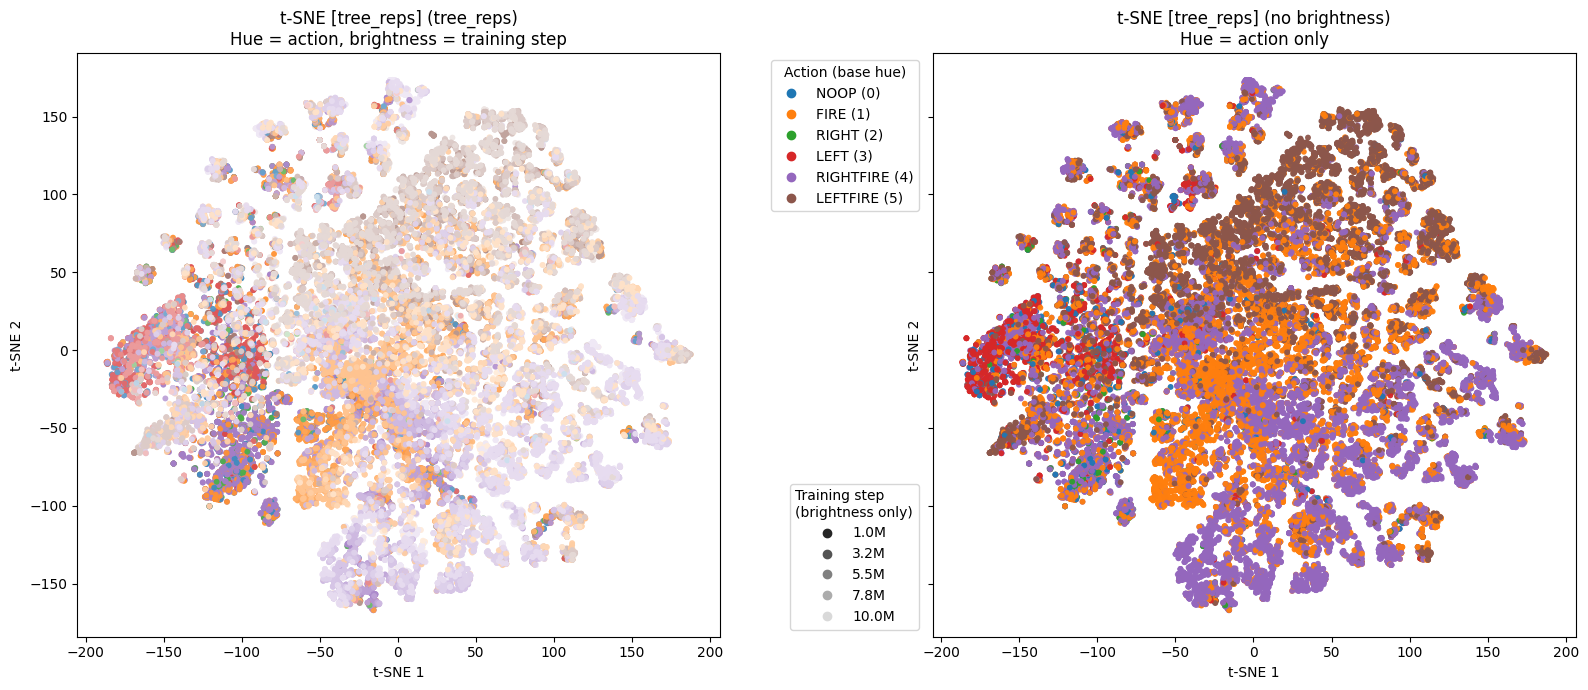

[t-SNE] real_imgs
[loaded] spaceinvaders_10e6_0.npy            pairs= 2219  step=10.0M  source=real_imgs
[loaded] spaceinvaders_10e6_1.npy            pairs= 3564  step=10.0M  source=real_imgs
[loaded] spaceinvaders_10e6_2.npy            pairs= 3481  step=10.0M  source=real_imgs
[loaded] spaceinvaders_1e6_0.npy             pairs= 1007  step=1.0M  source=real_imgs
[loaded] spaceinvaders_1e6_1.npy             pairs=  852  step=1.0M  source=real_imgs
[loaded] spaceinvaders_1e6_2.npy             pairs=  947  step=1.0M  source=real_imgs
[loaded] spaceinvaders_2e6_0.npy             pairs=  855  step=2.0M  source=real_imgs
[loaded] spaceinvaders_2e6_1.npy             pairs=  908  step=2.0M  source=real_imgs
[loaded] spaceinvaders_2e6_2.npy             pairs= 1106  step=2.0M  source=real_imgs
[loaded] spaceinvaders_3e6_0.npy             pairs=  943  step=3.0M  source=real_imgs
[loaded] spaceinvaders_3e6_1.npy             pairs=  890  step=3.0M  source=real_imgs
[loaded] spaceinvaders_3e6_2.npy 

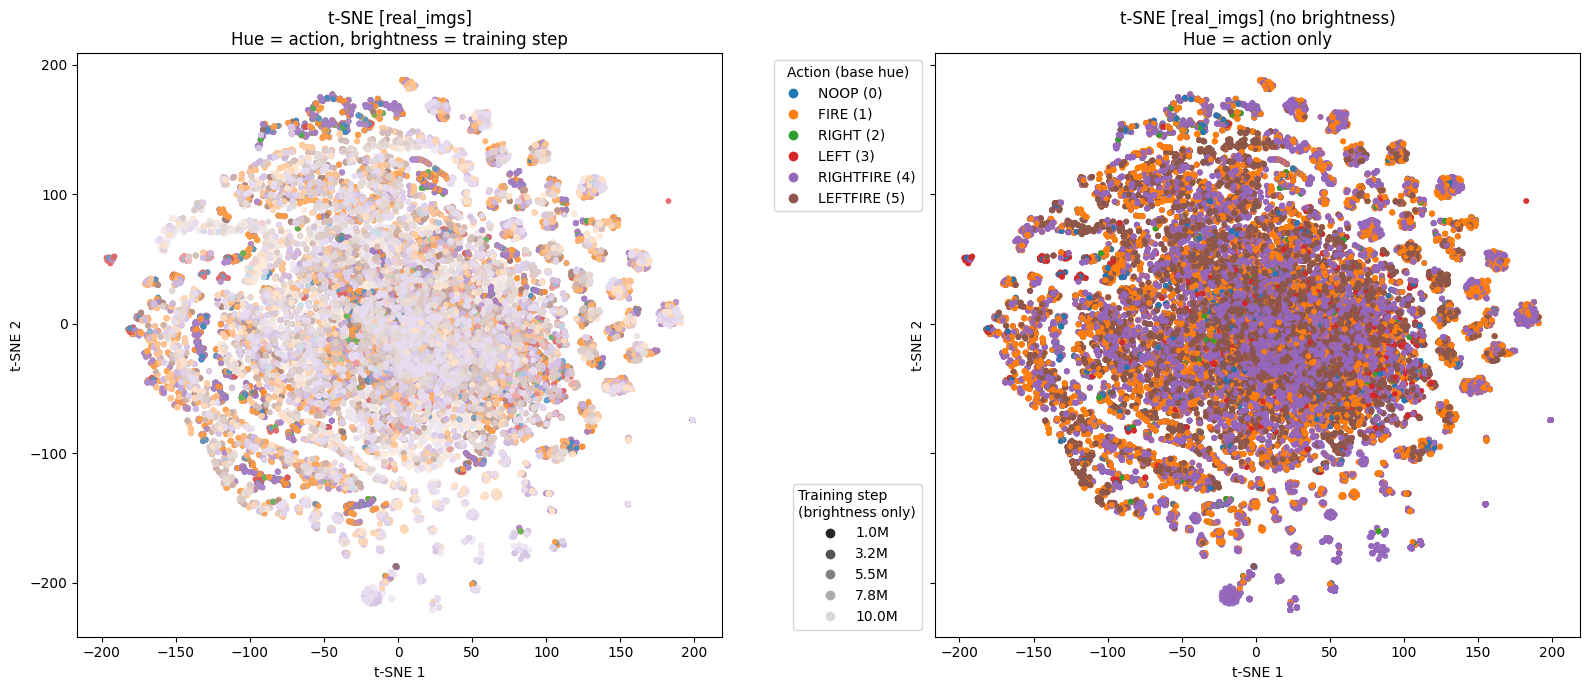

[t-SNE] real_vectors
[loaded] spaceinvaders_10e6_0.npy            pairs= 2219  step=10.0M  source=real_vectors
[loaded] spaceinvaders_10e6_1.npy            pairs= 3564  step=10.0M  source=real_vectors
[loaded] spaceinvaders_10e6_2.npy            pairs= 3481  step=10.0M  source=real_vectors
[loaded] spaceinvaders_1e6_0.npy             pairs= 1007  step=1.0M  source=real_vectors
[loaded] spaceinvaders_1e6_1.npy             pairs=  852  step=1.0M  source=real_vectors
[loaded] spaceinvaders_1e6_2.npy             pairs=  947  step=1.0M  source=real_vectors
[loaded] spaceinvaders_2e6_0.npy             pairs=  855  step=2.0M  source=real_vectors
[loaded] spaceinvaders_2e6_1.npy             pairs=  908  step=2.0M  source=real_vectors
[loaded] spaceinvaders_2e6_2.npy             pairs= 1106  step=2.0M  source=real_vectors
[loaded] spaceinvaders_3e6_0.npy             pairs=  943  step=3.0M  source=real_vectors
[loaded] spaceinvaders_3e6_1.npy             pairs=  890  step=3.0M  source=real_vecto

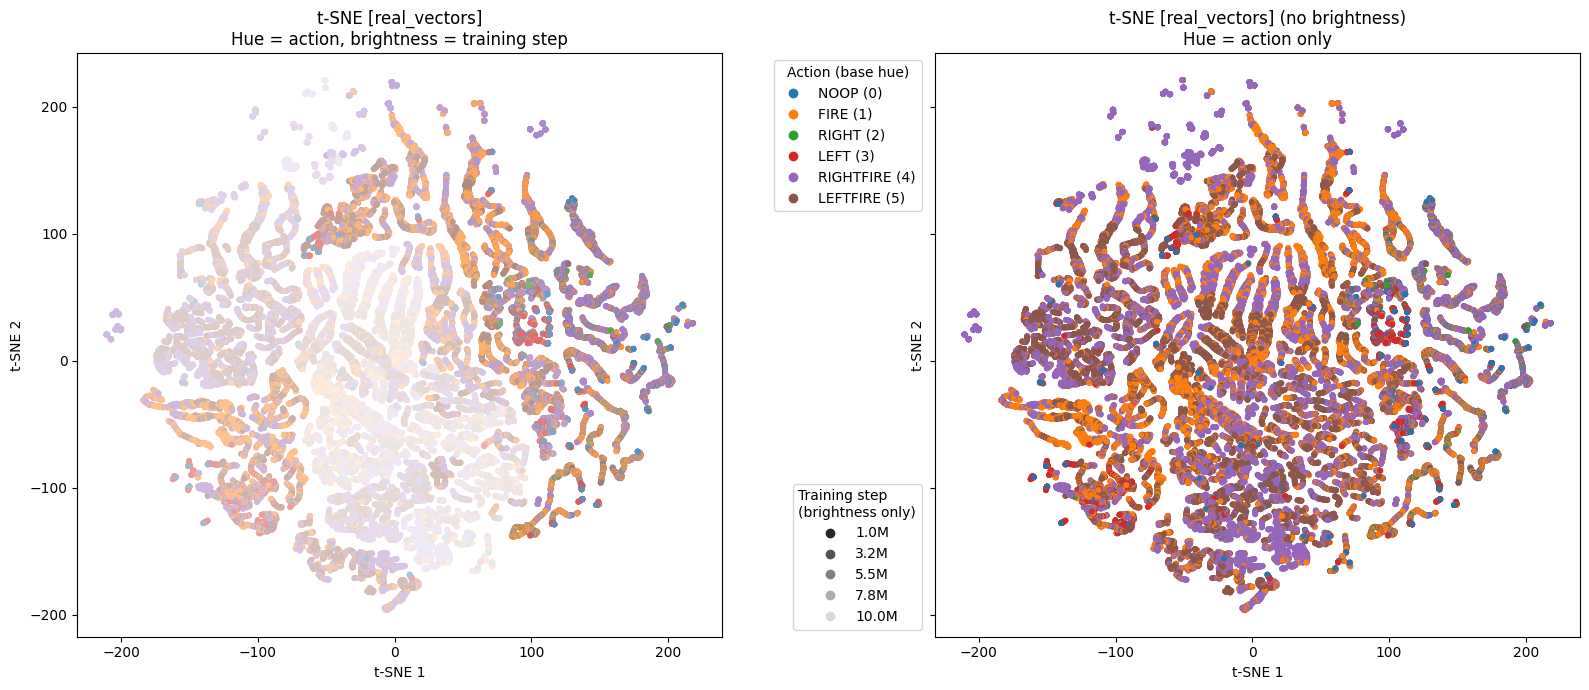

In [3]:
# Example usage --------------------------------------------------------------
tsne_tables = plot_multiple_tsne_targets(
    root_folder="test/spaceinvaderscheckpoint",
    shared_kwargs=dict(perplexity=25, stride=1, max_files=None, random_state=0),
    configs=[
        {"name": "tree_reps", "source": "tree_reps"},
        {"name": "real_imgs", "source": "real_imgs"},
        {"name": "real_vectors", "source": "real_vectors"},
    ],
)

In [30]:
"""Utilities for visualizing behavioral embeddings across checkpoints.

These helpers iterate over every ``.npy`` file inside a folder, extract the
planning snapshot that immediately precedes each real action (status==0), and
render 2-pane t‑SNE plots (left: hue+training-step brightness, right: hue-only).
Here the feature matrix is built by concatenating tree_reps fields with the
matching real_vectors entries at the same planning index.
"""

from __future__ import annotations

import math
import os
import re
from pathlib import Path
from typing import List, Optional, Sequence, Tuple, Union

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from openTSNE import TSNE, affinity, initialization

# ---------------------------------------------------------------------------
# Shared constants/helpers
# ---------------------------------------------------------------------------

ACTION_MAPPING = {
    "NOOP": 0,
    "FIRE": 1,
    "RIGHT": 2,
    "LEFT": 3,
    "RIGHTFIRE": 4,
    "LEFTFIRE": 5,
}
IDX_TO_ACTION = {v: k for k, v in ACTION_MAPPING.items()}

TRAINING_STEP_IN_NAME = re.compile(r"_(\d+(?:e\d+)?)(?=(?:_\d+)?\.npy$)", re.IGNORECASE)
TRAINING_STEP_IN_DIR = re.compile(r"(\d+(?:e\d+)?)$", re.IGNORECASE)
ALL_FIELD_SENTINELS = {"tree_reps", "all", "ALL", "*"}
EXCLUDED_TREE_REP_FIELDS: set[str] = set()


def _format_training_step(step: float) -> str:
    if step >= 1_000_000:
        return f"{step/1_000_000:.1f}M"
    if step >= 1_000:
        return f"{step/1_000:.1f}K"
    return f"{int(step)}"


# ---------------------------------------------------------------------------
# Status / pairing utilities
# ---------------------------------------------------------------------------

def analyze_status_data(status_data: Sequence[int]) -> Tuple[List[int], List[float], List[dict]]:
    real_indices: List[int] = []
    planning_depths: List[float] = []
    reset_info: List[dict] = []

    i = 0
    while i < len(status_data):
        if status_data[i] == 0:
            real_indices.append(i)
            imagination_start = i + 1
            imagination_end = len(status_data)
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break

            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                segment_lengths: List[int] = []
                current_length = 0
                reset_positions: List[int] = []

                for k, status_val in enumerate(imagination_segment):
                    if status_val in (1, 3):
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:
                        current_length += 1

                if current_length > 0:
                    segment_lengths.append(current_length)

                avg_planning_depth = float(np.mean(segment_lengths)) if segment_lengths else 0.0
                planning_depths.append(avg_planning_depth)
                reset_info.append(
                    {
                        "reset_positions": reset_positions,
                        "segment_lengths": segment_lengths,
                        "total_length": sum(segment_lengths),
                        "avg_planning_depth": avg_planning_depth,
                    }
                )
            else:
                planning_depths.append(0.0)
                reset_info.append(
                    {
                        "reset_positions": [],
                        "segment_lengths": [],
                        "total_length": 0,
                        "avg_planning_depth": 0.0,
                    }
                )

            i = imagination_end
        else:
            i += 1

    return real_indices, planning_depths, reset_info


def pair_real_and_planning_indices(status_data: Sequence[int]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    status_arr = np.asarray(status_data)
    real_indices, planning_depths_forward, _ = analyze_status_data(status_arr)

    paired_real: List[int] = []
    planning_indices: List[int] = []
    paired_depths: List[float] = []

    for pos in range(1, len(real_indices)):
        real_idx = real_indices[pos]
        cand = real_idx - 1
        while cand >= 0 and status_arr[cand] == 0:
            cand -= 1
        if cand < 0:
            continue
        paired_real.append(real_idx)
        planning_indices.append(cand)
        paired_depths.append(planning_depths_forward[pos - 1])

    return (
        np.asarray(paired_real, dtype=np.int64),
        np.asarray(planning_indices, dtype=np.int64),
        np.asarray(paired_depths, dtype=np.float32),
    )


def _normalize_tree_fields(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]]
) -> List[str]:
    if tree_fields is None:
        return [
            k
            for k, v in tree_reps.items()
            if isinstance(v, np.ndarray) and k not in EXCLUDED_TREE_REP_FIELDS
        ]

    if isinstance(tree_fields, str):
        if tree_fields in ALL_FIELD_SENTINELS:
            return _normalize_tree_fields(tree_reps, None)
        tree_fields = [tree_fields]

    filtered_fields = [f for f in tree_fields if f not in ALL_FIELD_SENTINELS]
    filtered_fields = [f for f in filtered_fields if f not in EXCLUDED_TREE_REP_FIELDS]
    if not filtered_fields:
        return _normalize_tree_fields(tree_reps, None)

    resolved = []
    missing = []
    for field in filtered_fields:
        if field in tree_reps:
            resolved.append(field)
        else:
            missing.append(field)

    if missing:
        raise KeyError(f"Missing tree_rep fields: {missing}")

    return resolved


def vectorize_tree_reps(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]] = None
) -> Tuple[np.ndarray, int]:
    fields = _normalize_tree_fields(tree_reps, tree_fields)
    lengths = [tree_reps[k].shape[0] for k in fields]
    common_len = int(min(lengths))

    vectors = []
    for key in fields:
        arr = np.asarray(tree_reps[key][:common_len])
        vectors.append(arr.reshape(common_len, -1))

    return np.concatenate(vectors, axis=1), common_len


def _flatten_step_array(arr: np.ndarray, max_len: Optional[int] = None) -> Tuple[np.ndarray, int]:
    arr = np.asarray(arr)
    if max_len is not None:
        arr = arr[:max_len]
    if arr.ndim == 1:
        flat = arr.reshape(arr.shape[0], 1)
    else:
        flat = arr.reshape(arr.shape[0], -1)
    return flat, flat.shape[0]


def prepare_real_step_matrix(
    data: dict,
    tree_fields: Optional[Union[str, Sequence[str]]] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    status_data = np.asarray(data["status"])
    real_indices, planning_indices, planning_depths = pair_real_and_planning_indices(status_data)

    if len(real_indices) == 0:
        raise ValueError("No usable real/planning pairs found.")

    tree_matrix, common_len = vectorize_tree_reps(data["tree_reps"], tree_fields=tree_fields)

    real_vecs = np.asarray(data.get("real_vectors"))
    if real_vecs is None or real_vecs.size == 0:
        raise ValueError("real_vectors missing or empty in dataset.")
    if real_vecs.shape[0] <= planning_indices.max():
        raise ValueError("real_vectors shorter than required planning indices.")
    real_vectors_flat = real_vecs.reshape(real_vecs.shape[0], -1)

    root_action_full = np.asarray(data["tree_reps"]["root_action"])
    if root_action_full.shape[0] <= real_indices.max():
        raise ValueError("root_action shorter than required real indices.")

    valid = (planning_indices < common_len) & (planning_indices < real_vectors_flat.shape[0])
    if not np.any(valid):
        raise ValueError("No valid indices remain after aligning tree reps and real_vectors.")
    planning_indices = planning_indices[valid]
    real_indices = real_indices[valid]
    planning_depths = planning_depths[valid]

    combined_features = np.concatenate(
        [tree_matrix[planning_indices], real_vectors_flat[planning_indices]],
        axis=1,
    )
    action_ids = np.argmax(root_action_full[real_indices], axis=1)

    return combined_features, action_ids, planning_depths, real_indices, planning_indices


# ---------------------------------------------------------------------------
# Dataset aggregation
# ---------------------------------------------------------------------------

def extract_training_step(path_like: Union[str, os.PathLike]) -> int:
    path = Path(path_like)
    name_match = TRAINING_STEP_IN_NAME.search(path.name)
    if name_match:
        token = name_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    dir_match = TRAINING_STEP_IN_DIR.search(path.parent.name)
    if dir_match:
        token = dir_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    for part in reversed(path.parent.parts):
        if part.startswith("thinker-"):
            chunks = part.split("-")
            for chunk in reversed(chunks):
                if chunk.isdigit() or TRAINING_STEP_IN_DIR.match(chunk or ""):
                    try:
                        return int(float(chunk))
                    except ValueError:
                        continue
    return 0


def build_tree_rep_dataset(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    max_files: Optional[int] = None,
    stride: int = 1,
    logger=print,
) -> dict:
    folder = Path(root_folder)
    npy_files = sorted(folder.glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError(f"No .npy files found under {folder}")

    all_vectors: List[np.ndarray] = []
    all_actions: List[np.ndarray] = []
    all_labels: List[np.ndarray] = []
    all_planning: List[np.ndarray] = []
    all_steps: List[np.ndarray] = []
    all_sources: List[np.ndarray] = []
    all_real_idx: List[np.ndarray] = []
    all_plan_idx: List[np.ndarray] = []

    for idx, npy_path in enumerate(npy_files):
        if max_files is not None and idx >= max_files:
            break
        try:
            data = np.load(npy_path, allow_pickle=True).item()
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to load {npy_path.name}: {exc}")
            continue

        try:
            (
                combined_features,
                action_ids,
                planning_depths,
                real_indices,
                planning_indices,
            ) = prepare_real_step_matrix(
                data, tree_fields=tree_fields
            )
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to parse {npy_path.name}: {exc}")
            continue

        if stride > 1:
            combined_features = combined_features[::stride]
            action_ids = action_ids[::stride]
            planning_depths = planning_depths[::stride]
            real_indices = real_indices[::stride]
            planning_indices = planning_indices[::stride]

        if combined_features.size == 0:
            continue

        training_step = extract_training_step(npy_path)
        step_arr = np.full(combined_features.shape[0], training_step, dtype=np.int64)
        source_arr = np.array([npy_path.name] * combined_features.shape[0])
        action_labels = np.vectorize(lambda a: IDX_TO_ACTION.get(int(a), f"A{int(a)}"))(action_ids)

        all_vectors.append(combined_features)
        all_actions.append(action_ids)
        all_labels.append(action_labels)
        all_planning.append(planning_depths)
        all_steps.append(step_arr)
        all_sources.append(source_arr)
        all_real_idx.append(real_indices.astype(np.int64))
        all_plan_idx.append(planning_indices.astype(np.int64))

        if logger:
            logger(
                f"[loaded] {npy_path.name:<35s} "
                f"pairs={combined_features.shape[0]:5d}  step={_format_training_step(training_step)}"
            )

    if not all_vectors:
        raise RuntimeError(f"No usable data found under {folder}.")

    def _stack(chunks: List[np.ndarray]) -> np.ndarray:
        return np.concatenate(chunks, axis=0)

    dataset = {
        "feature_matrix": _stack(all_vectors),
        "action_ids": _stack(all_actions),
        "action_labels": _stack(all_labels),
        "planning_depths": _stack(all_planning),
        "training_steps": _stack(all_steps),
        "source_files": _stack(all_sources),
        "real_indices": _stack(all_real_idx),
        "planning_indices": _stack(all_plan_idx),
    }

    return dataset


# ---------------------------------------------------------------------------
# Visualization helpers
# ---------------------------------------------------------------------------

def _mix_with_white(color: Union[str, Sequence[float]], strength: float) -> Tuple[float, float, float]:
    rgb = np.asarray(mcolors.to_rgb(color))
    strength = float(np.clip(strength, 0.0, 1.0))
    return tuple(rgb * (1.0 - strength) + strength)


def _compute_point_colors(action_ids: np.ndarray, training_steps: np.ndarray) -> Tuple[List[Tuple[float, float, float]], dict]:
    unique_actions = sorted(np.unique(action_ids))
    base_palette = sns.color_palette("tab10", n_colors=max(10, len(unique_actions)))
    base_color_map = {
        action: base_palette[action % len(base_palette)] for action in unique_actions
    }

    min_step = float(training_steps.min())
    max_step = float(training_steps.max())
    if math.isclose(min_step, max_step):
        norm = np.zeros_like(training_steps, dtype=float)
    else:
        norm = (training_steps - min_step) / (max_step - min_step)
    strengths = 0.15 + 0.7 * norm

    colors = []
    for action_id, strength in zip(action_ids, strengths):
        base = base_color_map[action_id]
        colors.append(_mix_with_white(base, float(strength)))

    return colors, base_color_map


def fit_tsne_opentsne(
    feature_matrix: np.ndarray,
    perplexity: int = 35,
    random_state: int = 0,
) -> np.ndarray:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(feature_matrix)
    base_perp = max(5, int(perplexity))
    large_perp = max(base_perp * 10, base_perp + 1)
    perplexities = sorted({base_perp, large_perp})
    affinities_multiscale = affinity.Multiscale(
        scaled,
        perplexities=perplexities,
        method="approx",
        metric="euclidean",
        n_jobs=-1,
        random_state=random_state,
    )
    init = initialization.pca(scaled, random_state=random_state)
    tsne = TSNE(
        n_components=2,
        n_jobs=-1,
        negative_gradient_method="fft",
        early_exaggeration_iter=250,
        early_exaggeration=12,
        n_iter=750,
        random_state=random_state,
    )
    embedding = tsne.fit(
        affinities=affinities_multiscale,
        initialization=init,
    )
    if len(perplexities) > 1:
        min_perp = float(min(perplexities))
        embedding.affinities.set_perplexities([min_perp])
        embedding = embedding.optimize(
            n_iter=250,
            exaggeration=1,
            momentum=0.8,
        )
    return np.asarray(embedding)


def plot_tree_rep_tsne_for_folder(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    perplexity: int = 35,
    random_state: int = 0,
    stride: int = 1,
    max_files: Optional[int] = None,
) -> dict:
    dataset = build_tree_rep_dataset(
        root_folder=root_folder,
        tree_fields=tree_fields,
        max_files=max_files,
        stride=stride,
    )
    emb = fit_tsne_opentsne(dataset["feature_matrix"], perplexity=perplexity, random_state=random_state)
    colors_with_brightness, base_color_map = _compute_point_colors(dataset["action_ids"], dataset["training_steps"])
    pure_colors = [base_color_map[a] for a in dataset["action_ids"]]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

    axes[0].scatter(emb[:, 0], emb[:, 1], c=colors_with_brightness, s=18, linewidths=0, alpha=0.95)
    axes[0].set_title("tree_reps + real_vectors t-SNE\nHue = action, brightness = training step")
    axes[0].set_xlabel("t-SNE 1")
    axes[0].set_ylabel("t-SNE 2")

    axes[1].scatter(emb[:, 0], emb[:, 1], c=pure_colors, s=18, linewidths=0, alpha=0.95)
    axes[1].set_title("tree_reps + real_vectors t-SNE\nHue = action only")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")

    action_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            color=base_color_map[action],
            label=f"{IDX_TO_ACTION.get(action, action)} ({action})",
        )
        for action in sorted(base_color_map)
    ]
    legend_actions = axes[0].legend(
        handles=action_handles,
        title="Action (base hue)",
        loc="upper right",
        bbox_to_anchor=(1.32, 1.0),
    )
    axes[0].add_artist(legend_actions)

    unique_steps = np.unique(dataset["training_steps"])
    sample_steps = unique_steps
    if unique_steps.size > 5:
        quantiles = np.linspace(0.0, 1.0, num=5)
        sample_steps = np.unique(np.round(np.quantile(unique_steps, quantiles)).astype(int))

    def _strength_for_step(step_val: float) -> float:
        min_step = float(unique_steps.min())
        max_step = float(unique_steps.max())
        if math.isclose(min_step, max_step):
            return 0.35
        norm = (step_val - min_step) / (max_step - min_step)
        return 0.15 + 0.7 * norm

    step_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            color=_mix_with_white("black", _strength_for_step(step)),
            label=_format_training_step(float(step)),
        )
        for step in sample_steps
    ]
    axes[0].legend(
        handles=step_handles,
        title="Training step\n(brightness only)",
        loc="lower right",
        bbox_to_anchor=(1.32, 0.0),
    )

    plt.tight_layout()
    plt.show()

    tsne_table = {
        "tsne_1": emb[:, 0],
        "tsne_2": emb[:, 1],
        "action_id": dataset["action_ids"],
        "action_label": dataset["action_labels"],
        "training_step": dataset["training_steps"],
        "planning_depth": dataset["planning_depths"],
        "source_file": dataset["source_files"],
        "real_index": dataset["real_indices"],
        "planning_index": dataset["planning_indices"],
    }

    return tsne_table


def plot_multiple_tsne_targets(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = None,
    shared_kwargs: Optional[dict] = None,
) -> dict:
    shared_kwargs = dict(shared_kwargs) if shared_kwargs else {}
    print("=" * 80)
    print("[t-SNE] tree_reps + real_vectors")
    result = plot_tree_rep_tsne_for_folder(
        root_folder=root_folder,
        tree_fields=tree_fields,
        **shared_kwargs,
    )
    return {"tree_reps+real_vectors": result}


In [ ]:
tsne_tables = plot_multiple_tsne_targets(
    root_folder="test/spaceinvaderscheckpoint",
    shared_kwargs=dict(perplexity=50, stride=1, max_files=None, random_state=0),
    tree_fields=None,
)

[t-SNE] tree_reps + real_vectors


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f585571d720>>
Traceback (most recent call last):
  File "/home/jmme425/miniconda3/envs/thinker/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 797, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


[loaded] spaceinvaders_10e6_0.npy            pairs= 2219  step=10.0M


In [ ]:
"""Utilities for visualizing behavioral embeddings across checkpoints.

These helpers iterate over every ``.npy`` file inside a folder, extract the
planning snapshot that immediately precedes each real action (status==0), and
render an interactive 3‑D t‑SNE scatter using Plotly.  A toggle button lets
you switch between “Hue + training-step brightness” and “Hue only” color
modes.  The pairing logic works for tree_reps, real_imgs, real_vectors, etc.,
so you can compare multiple targets in one run.
"""

from __future__ import annotations

import math
import os
import re
from pathlib import Path
from typing import List, Optional, Sequence, Tuple, Union

import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go

# ---------------------------------------------------------------------------
# Shared constants/helpers
# ---------------------------------------------------------------------------

ACTION_MAPPING = {
    "NOOP": 0,
    "FIRE": 1,
    "RIGHT": 2,
    "LEFT": 3,
    "RIGHTFIRE": 4,
    "LEFTFIRE": 5,
}
IDX_TO_ACTION = {v: k for k, v in ACTION_MAPPING.items()}

TRAINING_STEP_IN_NAME = re.compile(r"_(\d+(?:e\d+)?)(?=(?:_\d+)?\.npy$)", re.IGNORECASE)
TRAINING_STEP_IN_DIR = re.compile(r"(\d+(?:e\d+)?)$", re.IGNORECASE)
ALL_FIELD_SENTINELS = {"tree_reps", "all", "ALL", "*"}
EXCLUDED_TREE_REP_FIELDS = {"cur_action", "root_action"}


def _format_training_step(step: float) -> str:
    if step >= 1_000_000:
        return f"{step/1_000_000:.1f}M"
    if step >= 1_000:
        return f"{step/1_000:.1f}K"
    return f"{int(step)}"


# ---------------------------------------------------------------------------
# Status / pairing utilities
# ---------------------------------------------------------------------------

def analyze_status_data(status_data: Sequence[int]) -> Tuple[List[int], List[float], List[dict]]:
    real_indices: List[int] = []
    planning_depths: List[float] = []
    reset_info: List[dict] = []

    i = 0
    while i < len(status_data):
        if status_data[i] == 0:
            real_indices.append(i)
            imagination_start = i + 1
            imagination_end = len(status_data)
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break

            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                segment_lengths: List[int] = []
                current_length = 0
                reset_positions: List[int] = []

                for k, status_val in enumerate(imagination_segment):
                    if status_val in (1, 3):
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:
                        current_length += 1

                if current_length > 0:
                    segment_lengths.append(current_length)

                avg_planning_depth = float(np.mean(segment_lengths)) if segment_lengths else 0.0
                planning_depths.append(avg_planning_depth)
                reset_info.append(
                    {
                        "reset_positions": reset_positions,
                        "segment_lengths": segment_lengths,
                        "total_length": sum(segment_lengths),
                        "avg_planning_depth": avg_planning_depth,
                    }
                )
            else:
                planning_depths.append(0.0)
                reset_info.append(
                    {
                        "reset_positions": [],
                        "segment_lengths": [],
                        "total_length": 0,
                        "avg_planning_depth": 0.0,
                    }
                )

            i = imagination_end
        else:
            i += 1

    return real_indices, planning_depths, reset_info


def pair_real_and_planning_indices(status_data: Sequence[int]) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    status_arr = np.asarray(status_data)
    real_indices, planning_depths_forward, _ = analyze_status_data(status_arr)

    paired_real: List[int] = []
    planning_indices: List[int] = []
    paired_depths: List[float] = []

    for pos in range(1, len(real_indices)):
        real_idx = real_indices[pos]
        cand = real_idx - 1
        while cand >= 0 and status_arr[cand] == 0:
            cand -= 1
        if cand < 0:
            continue
        paired_real.append(real_idx)
        planning_indices.append(cand)
        paired_depths.append(planning_depths_forward[pos - 1])

    return (
        np.asarray(paired_real, dtype=np.int64),
        np.asarray(planning_indices, dtype=np.int64),
        np.asarray(paired_depths, dtype=np.float32),
    )


def _normalize_tree_fields(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]]
) -> List[str]:
    if tree_fields is None:
        return [
            k
            for k, v in tree_reps.items()
            if isinstance(v, np.ndarray) and k not in EXCLUDED_TREE_REP_FIELDS
        ]

    if isinstance(tree_fields, str):
        if tree_fields in ALL_FIELD_SENTINELS:
            return _normalize_tree_fields(tree_reps, None)
        tree_fields = [tree_fields]

    filtered_fields = [f for f in tree_fields if f not in ALL_FIELD_SENTINELS]
    filtered_fields = [f for f in filtered_fields if f not in EXCLUDED_TREE_REP_FIELDS]
    if not filtered_fields:
        return _normalize_tree_fields(tree_reps, None)

    resolved = []
    missing = []
    for field in filtered_fields:
        if field in tree_reps:
            resolved.append(field)
        else:
            missing.append(field)

    if missing:
        raise KeyError(f"Missing tree_rep fields: {missing}")

    return resolved


def vectorize_tree_reps(
    tree_reps: dict, tree_fields: Optional[Union[str, Sequence[str]]] = None
) -> Tuple[np.ndarray, int]:
    fields = _normalize_tree_fields(tree_reps, tree_fields)
    lengths = [tree_reps[k].shape[0] for k in fields]
    common_len = int(min(lengths))

    vectors = []
    for key in fields:
        arr = np.asarray(tree_reps[key][:common_len])
        vectors.append(arr.reshape(common_len, -1))

    return np.concatenate(vectors, axis=1), common_len


def _flatten_step_array(arr: np.ndarray, max_len: Optional[int] = None) -> Tuple[np.ndarray, int]:
    arr = np.asarray(arr)
    if max_len is not None:
        arr = arr[:max_len]
    if arr.ndim == 1:
        flat = arr.reshape(arr.shape[0], 1)
    else:
        flat = arr.reshape(arr.shape[0], -1)
    return flat, flat.shape[0]


def prepare_real_step_matrix(
    data: dict,
    source: str = "tree_reps",
    tree_fields: Optional[Union[str, Sequence[str]]] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    status_data = np.asarray(data["status"])
    real_indices, planning_indices, planning_depths = pair_real_and_planning_indices(status_data)

    if len(real_indices) == 0:
        raise ValueError("No usable real/planning pairs found.")

    if source == "tree_reps":
        matrix, common_len = vectorize_tree_reps(data["tree_reps"], tree_fields=tree_fields)
    else:
        if source not in data:
            raise KeyError(f"Source '{source}' not present in data keys: {list(data.keys())}")
        limit = min(len(data[source]), len(status_data))
        matrix, common_len = _flatten_step_array(data[source], max_len=limit)

    root_action_full = np.asarray(data["tree_reps"]["root_action"])
    root_len = root_action_full.shape[0]

    valid = (planning_indices < common_len) & (real_indices < root_len)
    if not np.any(valid):
        raise ValueError(f"No valid indices remain after aligning '{source}' with status array.")

    planning_indices = planning_indices[valid]
    real_indices = real_indices[valid]
    planning_depths = planning_depths[valid]

    features = matrix[planning_indices]
    action_ids = np.argmax(root_action_full[real_indices], axis=1)

    return features, action_ids, planning_depths, real_indices, planning_indices


# ---------------------------------------------------------------------------
# Dataset aggregation
# ---------------------------------------------------------------------------

def extract_training_step(path_like: Union[str, os.PathLike]) -> int:
    path = Path(path_like)
    name_match = TRAINING_STEP_IN_NAME.search(path.name)
    if name_match:
        token = name_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    dir_match = TRAINING_STEP_IN_DIR.search(path.parent.name)
    if dir_match:
        token = dir_match.group(1)
        try:
            return int(float(token))
        except ValueError:
            pass

    for part in reversed(path.parent.parts):
        if part.startswith("thinker-"):
            chunks = part.split("-")
            for chunk in reversed(chunks):
                if chunk.isdigit() or TRAINING_STEP_IN_DIR.match(chunk or ""):
                    try:
                        return int(float(chunk))
                    except ValueError:
                        continue
    return 0


def build_tree_rep_dataset(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    source: str = "tree_reps",
    max_files: Optional[int] = None,
    stride: int = 1,
    logger=print,
) -> dict:
    folder = Path(root_folder)
    npy_files = sorted(folder.glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError(f"No .npy files found under {folder}")

    all_vectors: List[np.ndarray] = []
    all_actions: List[np.ndarray] = []
    all_labels: List[np.ndarray] = []
    all_planning: List[np.ndarray] = []
    all_steps: List[np.ndarray] = []
    all_sources: List[np.ndarray] = []
    all_real_idx: List[np.ndarray] = []
    all_plan_idx: List[np.ndarray] = []

    for idx, npy_path in enumerate(npy_files):
        if max_files is not None and idx >= max_files:
            break
        try:
            data = np.load(npy_path, allow_pickle=True).item()
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to load {npy_path.name}: {exc}")
            continue

        try:
            (
                tree_real,
                action_ids,
                planning_depths,
                real_indices,
                planning_indices,
            ) = prepare_real_step_matrix(
                data, source=source, tree_fields=tree_fields
            )
        except Exception as exc:
            if logger:
                logger(f"[skip] Failed to parse {npy_path.name}: {exc}")
            continue

        if stride > 1:
            tree_real = tree_real[::stride]
            action_ids = action_ids[::stride]
            planning_depths = planning_depths[::stride]
            real_indices = real_indices[::stride]
            planning_indices = planning_indices[::stride]

        if tree_real.size == 0:
            continue

        training_step = extract_training_step(npy_path)
        step_arr = np.full(tree_real.shape[0], training_step, dtype=np.int64)
        source_arr = np.array([npy_path.name] * tree_real.shape[0])
        action_labels = np.vectorize(lambda a: IDX_TO_ACTION.get(int(a), f"A{int(a)}"))(action_ids)

        all_vectors.append(tree_real)
        all_actions.append(action_ids)
        all_labels.append(action_labels)
        all_planning.append(planning_depths)
        all_steps.append(step_arr)
        all_sources.append(source_arr)
        all_real_idx.append(real_indices.astype(np.int64))
        all_plan_idx.append(planning_indices.astype(np.int64))

        if logger:
            logger(
                f"[loaded] {npy_path.name:<35s} "
                f"pairs={tree_real.shape[0]:5d}  step={_format_training_step(training_step)}  source={source}"
            )

    if not all_vectors:
        raise RuntimeError(f"No usable tree_reps found under {folder}.")

    def _stack(chunks: List[np.ndarray]) -> np.ndarray:
        return np.concatenate(chunks, axis=0)

    dataset = {
        "tree_matrix": _stack(all_vectors),
        "action_ids": _stack(all_actions),
        "action_labels": _stack(all_labels),
        "planning_depths": _stack(all_planning),
        "training_steps": _stack(all_steps),
        "source_files": _stack(all_sources),
        "real_indices": _stack(all_real_idx),
        "planning_indices": _stack(all_plan_idx),
    }

    return dataset


# ---------------------------------------------------------------------------
# Visualization helpers
# ---------------------------------------------------------------------------

def _mix_with_white(color: Union[str, Sequence[float]], strength: float) -> Tuple[float, float, float]:
    rgb = np.asarray(mcolors.to_rgb(color))
    strength = float(np.clip(strength, 0.0, 1.0))
    return tuple(rgb * (1.0 - strength) + strength)


def _compute_point_colors(action_ids: np.ndarray, training_steps: np.ndarray) -> Tuple[List[Tuple[float, float, float]], dict]:
    unique_actions = sorted(np.unique(action_ids))
    base_palette = sns.color_palette("tab10", n_colors=max(10, len(unique_actions)))
    base_color_map = {
        action: base_palette[action % len(base_palette)] for action in unique_actions
    }

    min_step = float(training_steps.min())
    max_step = float(training_steps.max())
    if math.isclose(min_step, max_step):
        norm = np.zeros_like(training_steps, dtype=float)
    else:
        norm = (training_steps - min_step) / (max_step - min_step)
    strengths = 0.15 + 0.7 * norm

    colors = []
    for action_id, strength in zip(action_ids, strengths):
        base = base_color_map[action_id]
        colors.append(_mix_with_white(base, float(strength)))

    return colors, base_color_map


def _rgb_tuple_to_hex(rgb_tuple: Tuple[float, float, float]) -> str:
    r, g, b = [int(max(0, min(255, round(c * 255)))) for c in rgb_tuple]
    return f"#{r:02x}{g:02x}{b:02x}"


def fit_tsne(tree_matrix: np.ndarray, perplexity: int = 30, random_state: int = 0, n_components: int = 2) -> np.ndarray:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(tree_matrix)
    tsne = TSNE(
        n_components=n_components,
        perplexity=perplexity,
        random_state=random_state,
        init="pca",
        learning_rate="auto",
        max_iter=1000,
        verbose=1,
    )
    return tsne.fit_transform(scaled)


def plot_tree_rep_tsne_for_folder(
    root_folder: Union[str, os.PathLike],
    tree_fields: Optional[Union[str, Sequence[str]]] = "tree_reps",
    source: str = "tree_reps",
    perplexity: int = 35,
    random_state: int = 0,
    stride: int = 1,
    max_files: Optional[int] = None,
) -> dict:
    dataset = build_tree_rep_dataset(
        root_folder=root_folder,
        tree_fields=tree_fields,
        source=source,
        max_files=max_files,
        stride=stride,
    )
    emb_3d = fit_tsne(dataset["tree_matrix"], perplexity=perplexity, random_state=random_state, n_components=3)

    colors_with_brightness, base_color_map = _compute_point_colors(dataset["action_ids"], dataset["training_steps"])
    pure_colors = [base_color_map[a] for a in dataset["action_ids"]]
    step_colors_hex = [_rgb_tuple_to_hex(c) for c in colors_with_brightness]
    pure_colors_hex = [_rgb_tuple_to_hex(c) for c in pure_colors]

    if source == "tree_reps":
        if tree_fields is None:
            fields_label = "all fields"
        elif isinstance(tree_fields, (list, tuple)):
            fields_label = " + ".join(tree_fields)
        else:
            fields_label = str(tree_fields)
        title_suffix = f" ({fields_label})"
    else:
        title_suffix = ""

    hover_text = [
        f"action={IDX_TO_ACTION.get(int(a), a)}<br>step={_format_training_step(int(step))}<br>planning_depth={depth:.2f}"
        for a, step, depth in zip(dataset["action_ids"], dataset["training_steps"], dataset["planning_depths"])
    ]

    trace_step = go.Scatter3d(
        x=emb_3d[:, 0],
        y=emb_3d[:, 1],
        z=emb_3d[:, 2],
        mode="markers",
        name="Hue + step brightness",
        marker=dict(size=4, color=step_colors_hex, opacity=0.9),
        hovertext=hover_text,
        hoverinfo="text",
        visible=True,
    )

    trace_pure = go.Scatter3d(
        x=emb_3d[:, 0],
        y=emb_3d[:, 1],
        z=emb_3d[:, 2],
        mode="markers",
        name="Hue only",
        marker=dict(size=4, color=pure_colors_hex, opacity=0.9),
        hovertext=hover_text,
        hoverinfo="text",
        visible=False,
    )

    fig = go.Figure(data=[trace_step, trace_pure])
    fig.update_layout(
        title=f"3D t-SNE [{source}]{title_suffix}",
        scene=dict(
            xaxis_title="t-SNE 1",
            yaxis_title="t-SNE 2",
            zaxis_title="t-SNE 3",
        ),
        legend=dict(itemsizing="constant"),
        updatemenus=[
            dict(
                type="buttons",
                direction="right",
                x=0.0,
                y=1.12,
                buttons=[
                    dict(
                        label="Hue + Step",
                        method="update",
                        args=[{"visible": [True, False]}],
                    ),
                    dict(
                        label="Hue Only",
                        method="update",
                        args=[{"visible": [False, True]}],
                    ),
                ],
            )
        ],
    )
    fig.show()

    tsne_table = {
        "tsne_1": emb_3d[:, 0],
        "tsne_2": emb_3d[:, 1],
        "tsne_3": emb_3d[:, 2],
        "action_id": dataset["action_ids"],
        "action_label": dataset["action_labels"],
        "training_step": dataset["training_steps"],
        "planning_depth": dataset["planning_depths"],
        "source_file": dataset["source_files"],
        "real_index": dataset["real_indices"],
        "planning_index": dataset["planning_indices"],
    }

    return tsne_table


def plot_multiple_tsne_targets(
    root_folder: Union[str, os.PathLike],
    configs: Optional[Sequence[dict]] = None,
    shared_kwargs: Optional[dict] = None,
) -> dict:
    shared_kwargs = dict(shared_kwargs) if shared_kwargs else {}
    if configs is None:
        configs = [
            {"name": "tree_reps", "source": "tree_reps"},
            {"name": "real_imgs", "source": "real_imgs"},
            {"name": "real_vectors", "source": "real_vectors"},
        ]

    results = {}
    for cfg in configs:
        cfg = cfg.copy()
        name = cfg.pop("name", cfg.get("source", "tree_reps"))
        print("=" * 80)
        print(f"[t-SNE] {name}")
        local_kwargs = {**shared_kwargs, **cfg}
        results[name] = plot_tree_rep_tsne_for_folder(
            root_folder=root_folder,
            **local_kwargs,
        )

    return results


# Example usage --------------------------------------------------------------
tsne_tables = plot_multiple_tsne_targets(
    root_folder="test/spaceinvaderscheckpoint",
    shared_kwargs=dict(perplexity=35, stride=1, max_files=None, random_state=0),
    configs=[
        {"name": "tree_reps", "source": "tree_reps"},
        {"name": "real_imgs", "source": "real_imgs"},
        {"name": "real_vectors", "source": "real_vectors"},
    ],
)


action별 통계량 계산

In [8]:
from pathlib import Path
from collections import defaultdict
import pandas as pd 

root_folder = "test/spaceinvaderscheckpoint"
npy_files = sorted(Path(root_folder).glob("*.npy"))
if not npy_files:
    raise FileNotFoundError(f"No .npy files under {root_folder}")

def _init_stats():
    return {
        "num_samples": 0,
        "num_elements": 0,
        "sum": 0.0,
        "sum_sq": 0.0,
        "min": np.inf,
        "max": -np.inf,
        "norm_sum": 0.0,
    }

def pair_real_and_planning_indices(status_data):
    status_arr = np.asarray(status_data)
    real_indices, planning_depths, _ = analyze_status_data(status_arr)
    paired_real, planning_idx, depths = [], [], []

    for pos in range(1, len(real_indices)):
        real_idx = real_indices[pos]
        cand = real_idx - 1
        while cand >= 0 and status_arr[cand] == 0:
            cand -= 1
        if cand < 0:
            continue
        paired_real.append(real_idx)
        planning_idx.append(cand)
        depths.append(planning_depths[pos - 1])

    return (
        np.asarray(paired_real, dtype=np.int64),
        np.asarray(planning_idx, dtype=np.int64),
        np.asarray(depths, dtype=np.float32),
    )

field_meta = {}
field_action_stats = defaultdict(lambda: defaultdict(_init_stats))

for npy_path in npy_files:
    data = np.load(npy_path, allow_pickle=True).item()
    tree_reps = data["tree_reps"]
    status = np.asarray(data["status"])
    real_indices, plan_indices, _ = pair_real_and_planning_indices(status)
    if real_indices.size == 0:
        continue

    root_action = np.asarray(tree_reps["root_action"])
    if root_action.shape[0] <= real_indices.max():
        continue

    action_ids = np.argmax(root_action[real_indices], axis=1)
    unique_actions = np.unique(action_ids)
    action_masks = {act: (action_ids == act) for act in unique_actions}

    for field_name, arr in tree_reps.items():
        arr = np.asarray(arr)
        if arr.ndim == 0 or not np.issubdtype(arr.dtype, np.number):
            continue
        if arr.shape[0] <= plan_indices.max():
            continue

        per_step_shape = arr.shape[1:]
        feature_dim = int(np.prod(per_step_shape)) if per_step_shape else 1
        if field_name not in field_meta:
            field_meta[field_name] = {
                "dtype": str(arr.dtype),
                "per_step_shape": per_step_shape,
                "feature_dim": feature_dim,
            }

        field_plan = arr[plan_indices]
        flat_plan = field_plan.reshape(field_plan.shape[0], -1).astype(np.float64)

        for action_id, mask in action_masks.items():
            action_values = flat_plan[mask]
            if action_values.size == 0:
                continue
            stats = field_action_stats[field_name][int(action_id)]
            stats["num_samples"] += action_values.shape[0]
            stats["num_elements"] += action_values.size
            stats["sum"] += action_values.sum()
            stats["sum_sq"] += np.square(action_values).sum()
            stats["min"] = min(stats["min"], float(action_values.min()))
            stats["max"] = max(stats["max"], float(action_values.max()))
            stats["norm_sum"] += np.linalg.norm(action_values, axis=1).sum()

field_meta_df = pd.DataFrame(
    [
        {
            "field": field,
            "dtype": meta["dtype"],
            "per_step_shape": meta["per_step_shape"],
            "feature_dim": meta["feature_dim"],
        }
        for field, meta in sorted(field_meta.items())
    ]
)
display(field_meta_df)

rows = []
for field, actions in field_action_stats.items():
    meta = field_meta.get(field, {})
    for action_id, stats in actions.items():
        elem = stats["num_elements"]
        mean_val = stats["sum"] / elem if elem else np.nan
        variance = stats["sum_sq"] / elem - mean_val**2 if elem else np.nan
        std_val = float(np.sqrt(max(variance, 0.0))) if elem else np.nan
        rows.append(
            {
                "field": field,
                "dtype": meta.get("dtype"),
                "per_step_shape": meta.get("per_step_shape"),
                "feature_dim": meta.get("feature_dim"),
                "action_id": action_id,
                "action_label": IDX_TO_ACTION.get(action_id, f"A{action_id}"),
                "num_real_steps": stats["num_samples"],
                "mean_value": mean_val,
                "std_value": std_val,
                "min_value": stats["min"],
                "max_value": stats["max"],
                "avg_l2_norm": stats["norm_sum"] / stats["num_samples"] if stats["num_samples"] else np.nan,
            }
        )

action_summary_df = pd.DataFrame(rows).sort_values(["field", "action_id"])
display(action_summary_df)

output_dir = Path("analysis_exports")
output_dir.mkdir(parents=True, exist_ok=True)

meta_path = output_dir / "tree_rep_field_meta.csv"
summary_path = output_dir / "tree_rep_action_summary.csv"

field_meta_df.to_csv(meta_path, index=False)
action_summary_df.to_csv(summary_path, index=False)

print(f"Saved field metadata to {meta_path}")
print(f"Saved action stats to {summary_path}")


,field,dtype,per_step_shape,feature_dim
0,action_seq,float32,"(246,)",246
1,cur_action,float32,"(6,)",6
2,cur_d,float32,"(1,)",1
3,cur_ns,float32,"(6,)",6
4,cur_policy,float32,"(6,)",6
5,cur_qs_max,float32,"(6,)",6
6,cur_qs_mean,float32,"(6,)",6
7,cur_r,float32,"(1,)",1
8,cur_raw_action,float32,"(0,)",0
9,cur_reset,float32,"(1,)",1


,field,dtype,per_step_shape,feature_dim,action_id,action_label,num_real_steps,mean_value,std_value,min_value,max_value,avg_l2_norm
132,action_seq,float32,"(246,)",246,0,NOOP,1139,0.078628,0.269157,0.000000,1.000000,3.843299
133,action_seq,float32,"(246,)",246,1,FIRE,13267,0.033896,0.180962,0.000000,1.000000,2.493303
137,action_seq,float32,"(246,)",246,2,RIGHT,432,0.109521,0.312292,0.000000,1.000000,4.749056
134,action_seq,float32,"(246,)",246,3,LEFT,1791,0.114484,0.318398,0.000000,1.000000,4.964399
135,action_seq,float32,"(246,)",246,4,RIGHTFIRE,16109,0.037545,0.190094,0.000000,1.000000,2.514826
...,...,...,...,...,...,...,...,...,...,...,...,...
19,root_v,float32,"(1,)",1,1,FIRE,13267,4.686644,2.047375,-0.328691,19.967466,4.686962
23,root_v,float32,"(1,)",1,2,RIGHT,432,1.876796,0.998863,-0.008210,5.811107,1.876834
20,root_v,float32,"(1,)",1,3,LEFT,1791,1.740715,1.310071,-0.244152,7.395360,1.741888
21,root_v,float32,"(1,)",1,4,RIGHTFIRE,16109,4.820497,2.146613,-0.418224,11.992599,4.820930


Saved field metadata to analysis_exports/tree_rep_field_meta.csv
Saved action stats to analysis_exports/tree_rep_action_summary.csv


forest model로 feature importance 계산

0:	learn: 1.7699559	test: 1.7703771	best: 1.7703771 (0)	total: 6.73s	remaining: 1h 52m 1s
100:	learn: 0.9896029	test: 1.0338099	best: 1.0338099 (100)	total: 11m 20s	remaining: 1h 40m 53s
200:	learn: 0.7712482	test: 0.8502338	best: 0.8502338 (200)	total: 22m 33s	remaining: 1h 29m 41s
300:	learn: 0.6669383	test: 0.7766347	best: 0.7766347 (300)	total: 33m 46s	remaining: 1h 18m 26s
400:	learn: 0.6043991	test: 0.7404625	best: 0.7404625 (400)	total: 44m 58s	remaining: 1h 7m 11s
500:	learn: 0.5605967	test: 0.7195859	best: 0.7195859 (500)	total: 56m 11s	remaining: 55m 57s
600:	learn: 0.5272410	test: 0.7074051	best: 0.7074051 (600)	total: 1h 7m 22s	remaining: 44m 43s
700:	learn: 0.4994358	test: 0.6996327	best: 0.6996327 (700)	total: 1h 18m 34s	remaining: 33m 30s
800:	learn: 0.4755454	test: 0.6940112	best: 0.6940112 (800)	total: 1h 29m 45s	remaining: 22m 17s
900:	learn: 0.4542912	test: 0.6901016	best: 0.6901016 (900)	total: 1h 40m 56s	remaining: 11m 5s
999:	learn: 0.4353785	test: 0.6874388	best:

,feature_index,importance
0,4,7.579459
1,7,6.956102
2,57,6.182349
3,37,5.575268
4,38,5.502166
5,8,5.487602
6,30,5.218982
7,98,4.147809
8,34,4.030583
9,25,3.332384


/tmp/ipykernel_2183237/55926546.py:337: RuntimeWarning: Mean of empty slice.
  "avg_importance": float(importances[slc].mean()),
/home/jmme425/miniconda3/envs/thinker/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,field,dim,total_importance,avg_importance
3,root_policy,6,26.863010,4.477168
14,cur_policy,6,21.543212,3.590535
6,root_ns,6,9.709760,1.618293
4,root_qs_mean,6,7.304654,1.217442
5,root_qs_max,6,7.198705,1.199784
19,cur_reset,1,6.182349,6.182349
11,cur_r,1,5.218982,5.218982
21,deprec,1,4.147809,4.147809
7,root_trail_r,1,3.243495,3.243495
15,cur_qs_mean,6,1.858613,0.309769


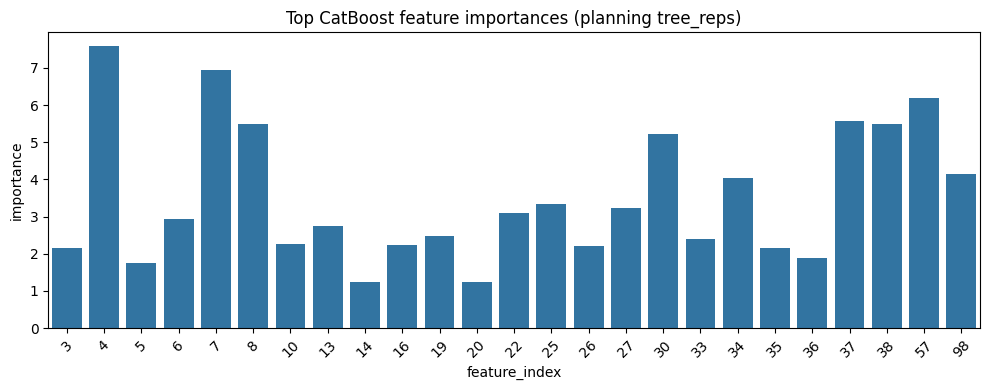

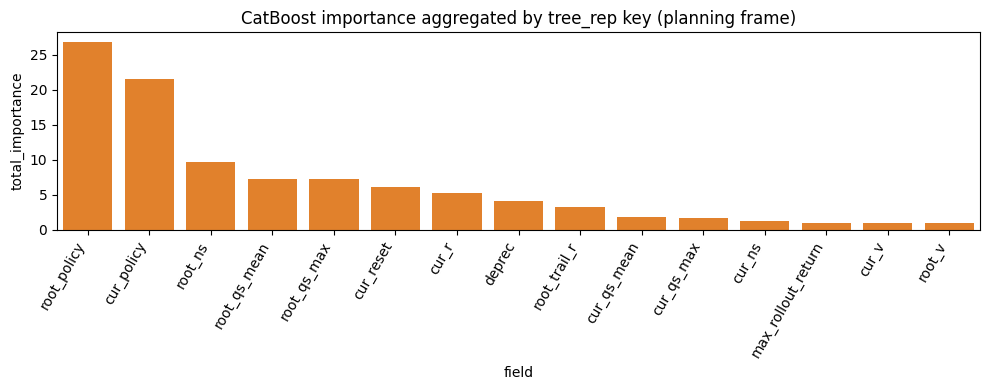

In [14]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

try:
    from catboost import CatBoostClassifier, Pool
except ImportError:
    %pip install catboost
    from catboost import CatBoostClassifier, Pool

# ------------------------------------------------------------------
# Helpers to fetch the planning snapshot immediately before status==0
# ------------------------------------------------------------------
def analyze_status_data(status_data):
    real_indices = []
    planning_depths = []
    reset_info = []

    i = 0
    while i < len(status_data):
        if status_data[i] == 0:
            real_indices.append(i)
            imagination_start = i + 1
            imagination_end = len(status_data)
            for j in range(i + 1, len(status_data)):
                if status_data[j] == 0:
                    imagination_end = j
                    break

            if imagination_start < imagination_end:
                imagination_segment = status_data[imagination_start:imagination_end]
                segment_lengths = []
                current_length = 0
                reset_positions = []

                for k, status_val in enumerate(imagination_segment):
                    if status_val in (1, 3):
                        if current_length > 0:
                            segment_lengths.append(current_length)
                        reset_positions.append(imagination_start + k)
                        current_length = 0
                    elif status_val == 2:
                        current_length += 1

                if current_length > 0:
                    segment_lengths.append(current_length)

                avg_depth = float(np.mean(segment_lengths)) if segment_lengths else 0.0
                planning_depths.append(avg_depth)
                reset_info.append(
                    {
                        "reset_positions": reset_positions,
                        "segment_lengths": segment_lengths,
                        "total_length": sum(segment_lengths),
                        "avg_planning_depth": avg_depth,
                    }
                )
            else:
                planning_depths.append(0.0)
                reset_info.append(
                    {
                        "reset_positions": [],
                        "segment_lengths": [],
                        "total_length": 0,
                        "avg_planning_depth": 0.0,
                    }
                )

            i = imagination_end
        else:
            i += 1

    return real_indices, planning_depths, reset_info


def pair_real_and_planning_indices(status_data):
    status_arr = np.asarray(status_data)
    real_indices, planning_depths, _ = analyze_status_data(status_arr)

    paired_real, planning_idx, depths = [], [], []
    for pos in range(1, len(real_indices)):
        real_idx = real_indices[pos]
        cand = real_idx - 1
        while cand >= 0 and status_arr[cand] == 0:
            cand -= 1
        if cand < 0:
            continue
        paired_real.append(real_idx)
        planning_idx.append(cand)
        depths.append(planning_depths[pos - 1])

    return (
        np.asarray(paired_real, dtype=np.int64),
        np.asarray(planning_idx, dtype=np.int64),
        np.asarray(depths, dtype=np.float32),
    )


def _normalize_tree_fields(tree_reps, tree_fields):
    excluded = {}
    if tree_fields is None:
        return [k for k, v in tree_reps.items() if k not in excluded and isinstance(v, (np.ndarray, list))]
    if isinstance(tree_fields, str):
        if tree_fields in {"tree_reps", "all", "ALL", "*"}:
            return _normalize_tree_fields(tree_reps, None)
        tree_fields = [tree_fields]
    filtered = [f for f in tree_fields if f not in {"tree_reps", "all", "ALL", "*"} and f not in excluded]
    return filtered or _normalize_tree_fields(tree_reps, None)


def vectorize_tree_reps(tree_reps, tree_fields=None):
    fields = _normalize_tree_fields(tree_reps, tree_fields)
    lengths = [np.asarray(tree_reps[k]).shape[0] for k in fields]
    common_len = int(min(lengths))

    vectors = []
    for key in fields:
        arr = np.asarray(tree_reps[key][:common_len])
        vectors.append(arr.reshape(common_len, -1))
    return np.concatenate(vectors, axis=1), common_len


def _flatten_step_array(arr, max_len=None):
    arr = np.asarray(arr)
    if max_len is not None:
        arr = arr[:max_len]
    if arr.ndim == 1:
        flat = arr.reshape(arr.shape[0], 1)
    else:
        flat = arr.reshape(arr.shape[0], -1)
    return flat, flat.shape[0]


def prepare_real_step_matrix(data, source="tree_reps", tree_fields=None):
    status_data = np.asarray(data["status"])
    real_indices, planning_indices, planning_depths = pair_real_and_planning_indices(status_data)
    if len(real_indices) == 0:
        raise ValueError("No usable real/planning pairs found.")

    if source == "tree_reps":
        matrix, common_len = vectorize_tree_reps(data["tree_reps"], tree_fields=tree_fields)
    else:
        if source not in data:
            raise KeyError(f"Source '{source}' not in data keys.")
        limit = min(len(data[source]), len(status_data))
        matrix, common_len = _flatten_step_array(data[source], max_len=limit)

    root_action_full = np.asarray(data["tree_reps"]["root_action"])
    root_len = root_action_full.shape[0]
    valid = (planning_indices < common_len) & (real_indices < root_len)
    if not np.any(valid):
        raise ValueError("No valid indices remain after alignment.")

    planning_indices = planning_indices[valid]
    real_indices = real_indices[valid]
    planning_depths = planning_depths[valid]

    features = matrix[planning_indices]
    action_ids = np.argmax(root_action_full[real_indices], axis=1)
    return features, action_ids, planning_depths, real_indices, planning_indices


def build_tree_rep_dataset(
    root_folder,
    tree_fields=None,
    source="tree_reps",
    max_files=None,
    stride=1,
    logger=print,
):
    folder = Path(root_folder)
    npy_files = sorted(folder.glob("*.npy"))
    if not npy_files:
        raise FileNotFoundError(f"No .npy files under {folder}")

    all_vectors, all_actions = [], []
    all_labels, all_planning = [], []
    all_steps, all_sources = [], []
    all_real_idx, all_plan_idx = [], []

    for idx, npy_path in enumerate(npy_files):
        if max_files is not None and idx >= max_files:
            break
        try:
            data = np.load(npy_path, allow_pickle=True).item()
        except Exception as exc:
            if logger:
                logger(f"[skip] load {npy_path.name}: {exc}")
            continue

        try:
            feats, action_ids, plan_depths, real_idx, plan_idx = prepare_real_step_matrix(
                data, source=source, tree_fields=tree_fields
            )
        except Exception as exc:
            if logger:
                logger(f"[skip] parse {npy_path.name}: {exc}")
            continue

        if stride > 1:
            feats = feats[::stride]
            action_ids = action_ids[::stride]
            plan_depths = plan_depths[::stride]
            real_idx = real_idx[::stride]
            plan_idx = plan_idx[::stride]

        if feats.size == 0:
            continue

        all_vectors.append(feats)
        all_actions.append(action_ids)
        all_labels.append(action_ids)  # action id doubles as label here
        all_planning.append(plan_depths)
        step_val = extract_training_step(npy_path)
        all_steps.append(np.full(feats.shape[0], step_val, dtype=np.int64))
        all_sources.append(np.array([npy_path.name] * feats.shape[0]))
        all_real_idx.append(real_idx.astype(np.int64))
        all_plan_idx.append(plan_idx.astype(np.int64))

        if logger:
            logger(f"[loaded] {npy_path.name:<35s} pairs={feats.shape[0]:5d}")

    if not all_vectors:
        raise RuntimeError(f"No usable data under {folder}")

    def _stack(chunks):
        return np.concatenate(chunks, axis=0)

    return {
        "tree_matrix": _stack(all_vectors),
        "action_ids": _stack(all_actions),
        "training_steps": _stack(all_steps),
        "planning_depths": _stack(all_planning),
        "source_files": _stack(all_sources),
        "real_indices": _stack(all_real_idx),
        "planning_indices": _stack(all_plan_idx),
    }


def compute_field_slices(example_tree_reps, tree_fields):
    fields = _normalize_tree_fields(example_tree_reps, tree_fields)
    slices = {}
    cursor = 0
    for field in fields:
        arr = np.asarray(example_tree_reps[field])
        field_dim = 1 if arr.ndim == 1 else int(np.prod(arr.shape[1:]))
        slices[field] = slice(cursor, cursor + field_dim)
        cursor += field_dim
    return fields, slices


def _is_numeric_step_array(arr):
    arr = np.asarray(arr)
    return arr.ndim >= 1 and np.issubdtype(arr.dtype, np.number)

def extract_training_step(path_like):
    path = Path(path_like)
    match = re.search(r"_(\d+(?:e\d+)?)(?=(?:_\d+)?\.npy$)", path.name, re.IGNORECASE)
    if match:
        try:
            return int(float(match.group(1)))
        except ValueError:
            pass
    return 0

# ------------------------------------------------------------------
# Load planning frames + train CatBoost
# ------------------------------------------------------------------
root_folder = "test/spaceinvaderscheckpoint"
npy_files = sorted(Path(root_folder).glob("*.npy"))
if not npy_files:
    raise FileNotFoundError(f"No .npy files under {root_folder}")

example_tree_reps = np.load(npy_files[0], allow_pickle=True).item()["tree_reps"]
exclude_fields = {"cur_action", "root_action", "action_seq"}
tree_fields = [
    key
    for key, value in example_tree_reps.items()
    if key not in exclude_fields and _is_numeric_step_array(value)
]

dataset = build_tree_rep_dataset(
    root_folder=root_folder,
    tree_fields=tree_fields,
    source="tree_reps",
    max_files=None,
    stride=1,
    logger=None,
)

resolved_fields, field_slices = compute_field_slices(example_tree_reps, tree_fields)

X = dataset["tree_matrix"]
y = dataset["action_ids"]
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0
)

train_pool = Pool(X_train, y_train)
valid_pool = Pool(X_valid, y_valid)

cat_model = CatBoostClassifier(
    iterations=1000,
    depth=15,
    learning_rate=0.01,
    loss_function="MultiClass",
    eval_metric="MultiClass",
    random_state=0,
    verbose=100,
)
cat_model.fit(train_pool, eval_set=valid_pool)

y_pred = cat_model.predict(valid_pool).astype(int).ravel()
val_accuracy = accuracy_score(y_valid, y_pred)
print(f"Validation accuracy: {val_accuracy:.4f}")

importances = cat_model.get_feature_importance(train_pool, type="FeatureImportance")
top_idx = np.argsort(importances)[::-1][:25]

importance_df = pd.DataFrame(
    {"feature_index": top_idx, "importance": importances[top_idx]}
)
display(importance_df)

field_rows = []
for field in resolved_fields:
    slc = field_slices[field]
    field_rows.append(
        {
            "field": field,
            "dim": slc.stop - slc.start,
            "total_importance": float(importances[slc].sum()),
            "avg_importance": float(importances[slc].mean()),
        }
    )
field_importance_df = pd.DataFrame(field_rows).sort_values("total_importance", ascending=False)
display(field_importance_df)

plt.figure(figsize=(10, 4))
sns.barplot(data=importance_df, x="feature_index", y="importance", color="tab:blue")
plt.title("Top CatBoost feature importances (planning tree_reps)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(
    data=field_importance_df.head(15),
    x="field",
    y="total_importance",
    color="tab:orange",
)
plt.title("CatBoost importance aggregated by tree_rep key (planning frame)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


유효 real step 수: 811
평균 planning depth: 10.04, 평균 total time: 0.176


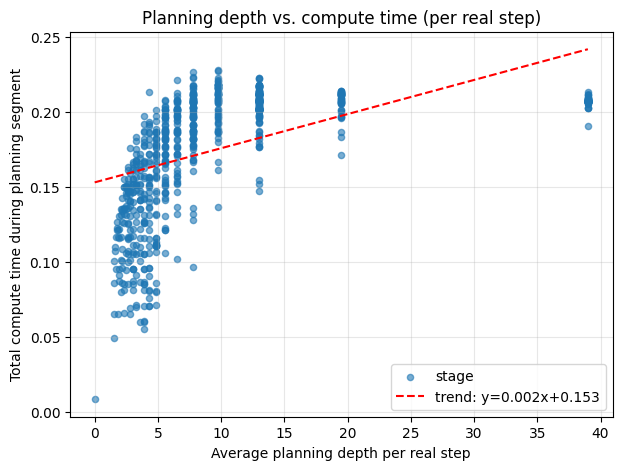

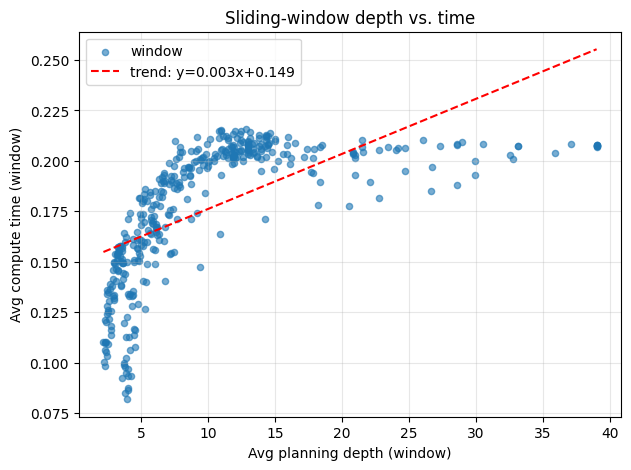

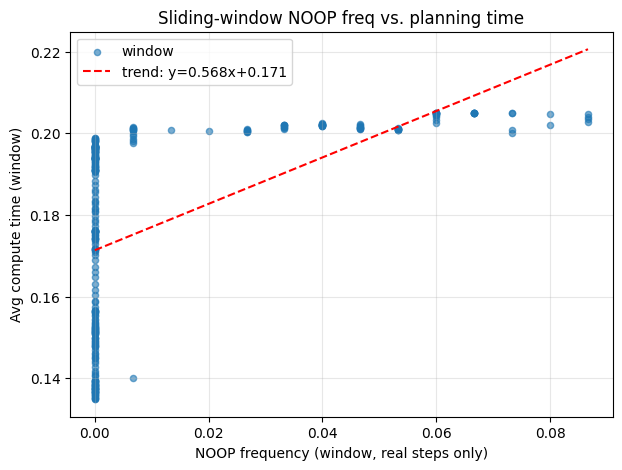

Linear projection correlation (R): 0.8254
Coefficient of determination (R^2): 0.6813


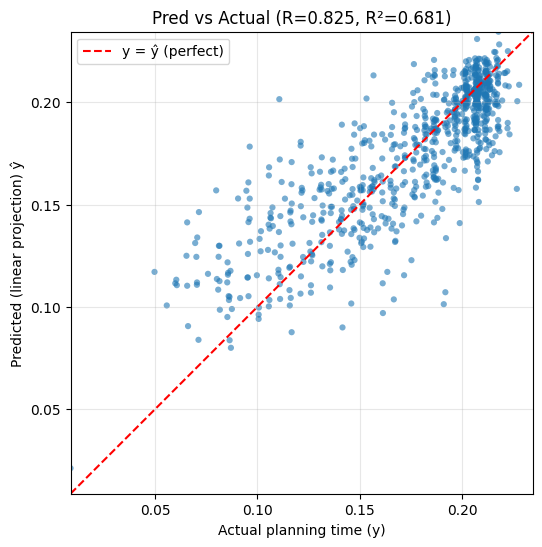

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# ==== helper: tree_reps flatten ====
def flatten_tree_reps(tree_reps):
    parts = [np.asarray(v) for v in tree_reps.values()]
    common_len = min(p.shape[0] for p in parts)
    parts = [p[:common_len].reshape(common_len, -1) for p in parts]
    return np.concatenate(parts, axis=1), common_len

# ==== 1) per-real-step planning depth & compute time ====
def compute_depth_time(data):
    status = np.asarray(data["status"])
    step_times = np.asarray(data.get("step_times"), dtype=float)

    min_len = min(len(status), len(step_times))
    status = status[:min_len]
    step_times = step_times[:min_len]

    real_idx, planning_depths, reset_info = analyze_status_data(status)

    segment_times = []
    for i, start in enumerate(real_idx):
        end = real_idx[i + 1] if i + 1 < len(real_idx) else len(status)
        seg_time = np.nansum(step_times[start:end])
        segment_times.append(seg_time)

    return np.array(real_idx), np.array(planning_depths, dtype=float), np.array(segment_times, dtype=float)

real_idx, planning_depths, segment_times = compute_depth_time(data)

mask = np.isfinite(planning_depths) & np.isfinite(segment_times)
pd_clean = planning_depths[mask]
st_clean = segment_times[mask]
print(f"유효 real step 수: {len(pd_clean)}")
print(f"평균 planning depth: {pd_clean.mean():.2f}, 평균 total time: {st_clean.mean():.3f}")

plt.figure(figsize=(7,5))
plt.scatter(pd_clean, st_clean, alpha=0.6, s=20, label="stage")
if len(pd_clean) > 1:
    coef = np.polyfit(pd_clean, st_clean, 1)
    x_line = np.linspace(pd_clean.min(), pd_clean.max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("Average planning depth per real step")
plt.ylabel("Total compute time during planning segment")
plt.title("Planning depth vs. compute time (per real step)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 2) Sliding window로 depth/time 관계 ====
def sliding_window_stats(values, times, window_size=10, stride=2):
    vals = np.asarray(values)
    tms = np.asarray(times)
    results = []
    for start in range(0, len(vals) - window_size + 1, stride):
        end = start + window_size
        win_vals = vals[start:end]
        win_tms = tms[start:end]
        results.append({
            "start": start,
            "end": end,
            "avg_depth": np.nanmean(win_vals),
            "avg_time": np.nanmean(win_tms),
        })
    return results

win_stats = sliding_window_stats(pd_clean, st_clean, window_size=10, stride=2)
win_depth = np.array([w["avg_depth"] for w in win_stats])
win_time = np.array([w["avg_time"] for w in win_stats])

plt.figure(figsize=(7,5))
plt.scatter(win_depth, win_time, alpha=0.6, s=20, label="window")
if len(win_depth) > 1:
    coef = np.polyfit(win_depth, win_time, 1)
    x_line = np.linspace(win_depth.min(), win_depth.max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("Avg planning depth (window)")
plt.ylabel("Avg compute time (window)")
plt.title("Sliding-window depth vs. time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 3) Sliding window로 NOOP 빈도 vs. planning time ====
noop_actions = []
cur_action = data["tree_reps"]["cur_action"]  # one-hot 가정
for i in range(len(real_idx)):
    idx = real_idx[i]
    if idx < len(cur_action):
        onehot = cur_action[idx]
        noop_actions.append(int(np.argmax(onehot)))
    else:
        noop_actions.append(-1)
noop_actions = np.array(noop_actions)

noop_clean = noop_actions[mask]

win_noop_freq = []
win_time2 = []
window_size = 150
stride = 2
for start in range(0, len(noop_clean) - window_size + 1, stride):
    end = start + window_size
    win_noop = noop_clean[start:end]
    win_tms = st_clean[start:end]
    valid = win_noop != -1
    if valid.any():
        freq = np.sum(win_noop[valid] == 0) / np.sum(valid)
    else:
        freq = np.nan
    win_noop_freq.append(freq)
    win_time2.append(np.nanmean(win_tms))
win_noop_freq = np.array(win_noop_freq)
win_time2 = np.array(win_time2)

plt.figure(figsize=(7,5))
plt.scatter(win_noop_freq, win_time2, alpha=0.6, s=20, label="window")
valid = np.isfinite(win_noop_freq) & np.isfinite(win_time2)
if valid.sum() > 1:
    coef = np.polyfit(win_noop_freq[valid], win_time2[valid], 1)
    x_line = np.linspace(win_noop_freq[valid].min(), win_noop_freq[valid].max(), 100)
    y_line = np.polyval(coef, x_line)
    plt.plot(x_line, y_line, 'r--', label=f"trend: y={coef[0]:.3f}x+{coef[1]:.3f}")
plt.xlabel("NOOP frequency (window, real steps only)")
plt.ylabel("Avg compute time (window)")
plt.title("Sliding-window NOOP freq vs. planning time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ==== 4) tree_reps_vector vs planning time: linear projection & multiple correlation ====
tree_matrix, common_len = flatten_tree_reps(data["tree_reps"])
driver_idx = real_idx - 1
valid = (driver_idx >= 0) & (driver_idx < common_len) & np.isfinite(segment_times)
X = tree_matrix[driver_idx[valid]]
y = segment_times[valid]

# 스케일링 후 선형회귀
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
reg = LinearRegression().fit(X_scaled, y)
y_hat = reg.predict(X_scaled)

# multiple correlation (corr of y_hat vs y) 및 R^2
R = np.corrcoef(y_hat, y)[0, 1]
R2 = reg.score(X_scaled, y)
print(f"Linear projection correlation (R): {R:.4f}")
print(f"Coefficient of determination (R^2): {R2:.4f}")

# y_hat, y가 위에서 계산된 상태라고 가정
plt.figure(figsize=(6,6))
plt.scatter(y, y_hat, alpha=0.6, s=20, edgecolor="none")
lims = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
plt.plot(lims, lims, 'r--', label="y = ŷ (perfect)")
plt.xlabel("Actual planning time (y)")
plt.ylabel("Predicted (linear projection) ŷ")
plt.title(f"Pred vs Actual (R={R:.3f}, R²={R2:.3f})")
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()
